<h1 style="text-align: center;">SMT Challenge 2025 Bayesian Analysis</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to conduct the Bayesian Analysis of the data + the quantification of Aggressiveness</h3>

### Necessary Libraries

In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import great_tables as gt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from matplotlib.ticker import FuncFormatter
scaler = StandardScaler()
from scipy.special import expit, logit

import arviz as az
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-colors")

import pytensor.tensor as pt
import pymc as pm
from scipy.stats import pearsonr

baby_blue_color = '#89CFF0'
red_color = '#CC3433'

pd.set_option('display.max_columns', None)

### Helper Functions

In [2]:
home_field_dim = {'QEA': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x)**2) + 400, lambda x: -((1/395) * (x)**2) + 400]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/240) * (x)**2) + 384, lambda x: -((1/325) * (x)**2) + 384])
                            },
                    'RZQ': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/380) * (x-60)**2) + 415, lambda x: -((1/340) * (x)**2) + 405]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/310) * (x-60)**2) + 399, lambda x: -((1/270) * (x)**2) + 389])
                            },
                    'YJD': {
                            'outfield_wall': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/300) * (x)**2) + 415, lambda x: -((1/288) * (x)**2) + 417]), 
                            'warning_track': lambda x: np.piecewise(x, [x < 0, x >= 0], [lambda x: -((1/230) * (x)**2) + 399, lambda x: -((1/235) * (x)**2) + 401])
                            }
                }

In [3]:
def opportunity_time(df: pd.DataFrame, game_str_id: str) -> float:
    """
    Calculates the opportunity time of the ball out of the pitcher's hand for that game_str_id
    Used for catch probability and gives credit to outfielders who anticipate the pitch
    
    Arguments: df: DataFrame, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## Calculates the end time of the ball's trajectory
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]
    if len(df[df['event_code'] == 9]) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]
    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]
    idx_dict = sorted(idx_dict, key=idx_dict.get)

    return round(df['elapsed_timestamp'].loc[df['event_code'] == idx_dict[0]].iloc[0], 3)

In [4]:
def dist_closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the distance of the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    return min(dist_fielders.values())

In [5]:
def direction_closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the direction of the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    Uses the same direction reasoning as direction angle in the EDA notebook
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    closest_teammate_pos = min(dist_fielders, key=dist_fielders.get)

    direct_fielders = {}
    if nearest_to_catch_pt == 7:
        direct_fielders[8] = update_angle(np.degrees((math.atan2(df['field_y_8'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_8'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[9] = update_angle(np.degrees((math.atan2(df['field_y_9'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_9'] - df[f'field_x_{nearest_to_catch_pt}']))))
    if nearest_to_catch_pt == 8:
        direct_fielders[7] = update_angle(np.degrees((math.atan2(df['field_y_7'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_7'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[9] = update_angle(np.degrees((math.atan2(df['field_y_9'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_9'] - df[f'field_x_{nearest_to_catch_pt}']))))
    if nearest_to_catch_pt == 9:
        direct_fielders[7] = update_angle(np.degrees((math.atan2(df['field_y_7'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_7'] - df[f'field_x_{nearest_to_catch_pt}']))))
        direct_fielders[8] = update_angle(np.degrees((math.atan2(df['field_y_8'] - df[f'field_y_{nearest_to_catch_pt}'], df['field_x_8'] - df[f'field_x_{nearest_to_catch_pt}']))))

    return direct_fielders[closest_teammate_pos]

In [6]:
def closest_teammate(df: pd.DataFrame, game_str_id: str):
    """
    Finds the closest teammate to the person who made the attempt at the point 1.5 sec before the landing/catch pt
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    ## looks at the 1.5 sec point to see how far the closest fielder is to the fielder who made the attempt
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    df = df.iloc[one_half_s_marker]

    dist_fielders = {}
    if nearest_to_catch_pt == 7:
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 8:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[9] = euclidean_distance(df['field_x_9'], df['field_y_9'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
    if nearest_to_catch_pt == 9:
        dist_fielders[7] = euclidean_distance(df['field_x_7'], df['field_y_7'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])
        dist_fielders[8] = euclidean_distance(df['field_x_8'], df['field_y_8'], df[f'field_x_{nearest_to_catch_pt}'], df[f'field_y_{nearest_to_catch_pt}'])

    return min(dist_fielders, key=dist_fielders.get)

In [7]:
def update_angle(direction_angle: float) -> str:
    """
    Helper function made to transform the direction angle between each an outfielder's position and the catch point
    Matches the description of 0º being in front and 180º in the back (following a clockwise motion starting from 0º)
    
    Arguments: direction_angle: an outfielder's direction angle towards the catch point based on the unit circle
    """
    if direction_angle < 0:
        direction_angle = direction_angle + 360
    if (0 <= direction_angle < 60) or (direction_angle==360):
        return 'Back Right'
    elif 60 <= direction_angle < 120:
        return 'Back'
    elif 120 <= direction_angle < 180:
        return 'Back Left'
    elif 180 <= direction_angle < 240:
        return 'In Left'
    elif 240 <= direction_angle < 300:
        return 'In'
    elif 300 <= direction_angle < 360:
        return 'In Right'

In [8]:
def jump_hists(df: pd.DataFrame, jump_metric: str) -> None:
    """
    Plots the histogram of each jump component vs avg
    
    Arguments: df: Dataframe, jump_metric: one of the jump metrics (vs avg)
    """
    plt.figure()
    sns.histplot(data=df, x=jump_metric, bins=20, color=baby_blue_color, stat='density')
    sns.kdeplot(data=df, x=jump_metric, color=red_color)
    plt.title(f'{jump_metric} Distribution')
    plt.show()

In [9]:
def aggressive_attempt(df: pd.DataFrame, game_str_id: str) -> int:
    """
    Dictates whether if game_str_id contains an aggressive attempt
    An aggressive attempt is defined as an outfielder putting their body on the line (e.g., diving, sliding, running into the wall)
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## automatically makes plays that aren't possible for fielders to catch on the first bounce a 0 (it wasn't possible for them to make an aggressive play on the ball)
    p_catch_zero = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'] == 0).iloc[0]
    distance_needed_zero = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_needed'].iloc[0]
    distance_traveled_zero = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_traveled'].iloc[0]
    distance_needed_traveled = distance_traveled_zero / distance_needed_zero
    if p_catch_zero and (distance_needed_traveled < 0.95):
        return 0
    
    ## makes sure the difficulty of the play is appropriate to be aggressive for (it filters those flyballs where the fielder slows down to get under the ball)
    ## it's possible that somebody can be aggressive on a 1-2 star level play -> qualification to be aggressive is at least a 3-star level difficulty play
    ## these will most likely not happen often --> without video it's hard to validate aggressiveness on these kind of plays
    valid_p_catch = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'] > 0.75).iloc[0]
    if valid_p_catch:
        return 0

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
            if game_str_id in not_aggressive_list:
                return 0
        else:
            catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff']#.iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff']#.iloc[2:]

    play_catch_prob = (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'].iloc[0] * 100)

    ## looks at the interval around the catch point (1.5 sec before and 0.5 sec after)
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    if df.iloc[-1]['elapsed_timestamp'] < (catch_time+0.5):
        half_s_after_marker = None
    else:
        half_s_after_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time+0.5, 1)]['elapsed_timestamp'] - round(catch_time+0.5, 1)).idxmin() + 1

    df = df.iloc[one_half_s_marker: half_s_after_marker].reset_index(drop=True).copy()

    first_one_half_s = df.iloc[0: df.loc[(df['event_code'] == idx_dict[0])].iloc[0].name + 1].copy()
    if idx_dict[0] == 2:
        second_half_s = df.iloc[df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))].iloc[0].name:].reset_index(drop=True).copy()
    else:
        second_half_s = df.iloc[df.loc[(df['event_code'] == idx_dict[0])].iloc[0].name:].reset_index(drop=True).copy()

    ## calculates dive/slide
    if (first_one_half_s[f'instantaneous_acc_{nearest_to_catch_pt}'] < -100).any():
        # print(f'{game_str_id}: Dive/Slide, Catch Prob: {play_catch_prob}%')
        return 1
    
    ## calculates running into the wall
    if (second_half_s[f'instantaneous_acc_{nearest_to_catch_pt}'] < -200).any():
        ## takes away the play where the fielder stops their momentum to throw instead of running into the wall
        if (second_half_s[second_half_s['event_code'] == 3].shape[0] >= 1) or ((second_half_s[second_half_s['event_code'] == 8].shape[0] >= 1)):
            return 0
        if (play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_to_wall']).iloc[0] <= 20:
            # print(f'{game_str_id}: Run Into Wall, Catch Prob: {play_catch_prob}%')
            return 1
    
    if game_str_id in aggressive_plays:
        return 1

    return 0

In [113]:
def visual_trajectory(df: pd.DataFrame, game_str_id: str) -> None:
    """
    Displays the route of the outfielder who made the attempt

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## figures out who gets credit for the route (meaning they made the catch or were the closest to the ball)
    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0]
    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = catch_point['player_position']
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0]
        acquisition_pt = df.loc[(df['event_code'] == 2) & (df['player_position'].isin([7, 8, 9]))].iloc[0]
        acq_x = acquisition_pt[f'field_x_{int(nearest_to_catch_pt)}']
        acq_y = acquisition_pt[f'field_y_{int(nearest_to_catch_pt)}']

    catch_x = catch_point[f'field_x_{int(nearest_to_catch_pt)}']
    catch_y = catch_point[f'field_y_{int(nearest_to_catch_pt)}']
    starting_x = df[f'field_x_{int(nearest_to_catch_pt)}'].iloc[0]
    starting_y = df[f'field_y_{int(nearest_to_catch_pt)}'].iloc[0]
    catch_time = catch_point['elapsed_timestamp']

    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    one_half_s_marker_x = df.iloc[one_half_s_marker][f'field_x_{int(nearest_to_catch_pt)}']
    one_half_s_marker_y = df.iloc[one_half_s_marker][f'field_y_{int(nearest_to_catch_pt)}']

    if nearest_to_catch_pt == '7':
        player_pos = 'Left Fielder'
    elif nearest_to_catch_pt == '8':
        player_pos = 'Center Fielder'
    elif nearest_to_catch_pt == '9':
        player_pos = 'Right Fielder'

    home_team = df[df['home_team'].notna()]['home_team'].unique()[0]
    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    plt.figure()
    sns.scatterplot(data=df, x=f'field_x_{int(nearest_to_catch_pt)}', y=f'field_y_{int(nearest_to_catch_pt)}', color='#89CFF0', s=75)
    if idx_dict[0] == 2:
        plt.scatter(catch_x, catch_y, color='#228B22', s=75, zorder=5, label='Catch Made')
        plt.scatter(one_half_s_marker_x, one_half_s_marker_y, color='black', s=50, zorder=5, label='1.5 Sec Mark Before Catch')
    else:
        plt.scatter(catch_x, catch_y, color='#CC3433', s=75, zorder=5, label='Landing Point')
        plt.scatter(one_half_s_marker_x, one_half_s_marker_y, color='black', s=50, zorder=5, label='1.5 Sec Mark Before Landing')
        plt.scatter(acq_x, acq_y, color='#228B22', s=50, zorder=5, label='Acquisition Point')
    plt.scatter(starting_x, starting_y, color='#0e3386', s=50, zorder=5, label='Starting Point')
    catch_prob_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['p_catch'].iloc[0] * 100
    distance_needed_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_needed'].iloc[0]
    distance_to_wall_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['distance_to_wall'].iloc[0]
    opportunity_time_text = play_data_w_catch_probs[play_data_w_catch_probs['game_str_id'] == game_str_id]['opportunity_time'].iloc[0]
    plt.annotate(f'Catch Prob: {catch_prob_text}%', (catch_x, catch_y), textcoords="offset points", xytext=(50, -20), ha='center')
    plt.annotate(f'Distance Needed: {round(distance_needed_text)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -35), ha='center')
    plt.annotate(f'Distance to Wall: {round(distance_to_wall_text, 1)} ft', (catch_x, catch_y), textcoords="offset points", xytext=(50, -50), ha='center')
    plt.annotate(f'Opportunity Time: {round(opportunity_time_text, 1)} sec', (catch_x, catch_y), textcoords="offset points", xytext=(50, -65), ha='center')
    plt.plot(field_vals, home_run_wall, c='black', zorder=0, label='Outfield Wall')
    plt.plot(field_vals, warning_track, c='white', zorder=0)
    plt.plot(lf_x_values, lf_foul_line, c='black', zorder=0)
    plt.plot(rf_x_values, rf_foul_line, c='black', zorder=0)
    plt.fill_between(field_vals, home_run_wall, warning_track, color='#765b4c', alpha=0.5, zorder=0, label='Warning Track Zone')
    plt.xlim(df[f'field_x_{int(nearest_to_catch_pt)}'].min()-5, df[f'field_x_{int(nearest_to_catch_pt)}'].max()+5)
    plt.ylim(df[f'field_y_{int(nearest_to_catch_pt)}'].min()-10, df[f'field_y_{int(nearest_to_catch_pt)}'].max()+8)
    plt.title(f"{player_pos}'s Route on Play {game_str_id}")
    plt.legend()
    plt.show()

    plot_velo_acc(df, game_str_id, int(nearest_to_catch_pt))

In [12]:
def stadium_walls(df: pd.DataFrame, home_team: str) -> None:
    """
    Visualizes some form of outline for each team's outfield wall + warning track (QEA, RZQ, YJD)
    I trial and error'd with the exact coefficients in the polynomials for the wall + warning track using the clusters of wall balls and homers

    Arguments: Dataframe, home team's name
    """
    df = df.copy()

    plt.figure(figsize=(8, 8))
    lf_x_values = np.linspace(0, -320)
    lf_foul_line = -lf_x_values
    rf_x_values = np.linspace(0, 320)
    rf_foul_line = rf_x_values

    if home_team == 'QEA':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    elif home_team == 'RZQ':
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)
    else:
        field_vals = np.linspace(-320, 320)
        home_run_wall = home_field_dim[home_team]['outfield_wall'](field_vals)
        warning_track = home_field_dim[home_team]['warning_track'](field_vals)

    stadium_wall_balls = df[(df['event_code_name'] == 'ball deflection off of wall') & (df['home_team'] == home_team)]

    plt.plot(lf_x_values, lf_foul_line, c='red')
    plt.plot(rf_x_values, rf_foul_line, c='red')
    plt.plot(field_vals, home_run_wall, c='red')
    plt.plot(field_vals, warning_track, c='red')
    # plt.ylim(0, 500)
    plt.legend()
    plt.show()

In [13]:
def distance_needed(df: pd.DataFrame, game_str_id: str):
    """
    Calculates the needed distance between the outfielder's position coordinates and the ball's catch point (where it's caught or where it first bounces)
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## fixes the game ids that have messed up timestamp intervals and adds in the missing values
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## Each outfielder's starting position (player_pos_x, player_pos_y)
    starting_coords = df.iloc[0]
    lf_starting_coords = starting_coords[['field_x_7', 'field_y_7']]
    cf_starting_coords = starting_coords[['field_x_8', 'field_y_8']]
    rf_starting_coords = starting_coords[['field_x_9', 'field_y_9']]

    ## Calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)
    catch_point = df.loc[df['event_code'] == idx_dict[0]].iloc[0][['ball_position_x', 'ball_position_y']]

    play_made_coords = catch_point

    distance_needed_7 = euclidean_distance(lf_starting_coords.iloc[0], lf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_8 = euclidean_distance(cf_starting_coords.iloc[0], cf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])
    distance_needed_9 = euclidean_distance(rf_starting_coords.iloc[0], rf_starting_coords.iloc[1], play_made_coords.iloc[0], play_made_coords.iloc[1])

    return np.array([distance_needed_7, distance_needed_8, distance_needed_9])

In [14]:
def attempt_metric_creator(df: pd.DataFrame, col_name: str) -> pd.DataFrame:
    """
    Creates the column of a metric in df that has multiple columns for each fielder
    Bases it on who made the attempt (which has been talked about how that works) 
    
    Arguments: df: Dataframe, col_name: some metric with columns for each fielder
    """
    df = df.copy()
    df.loc[:, col_name] = np.where(df['player_attempt'] == 7, 
                                           df[f'{col_name}_7'],
                                           np.where(
                                               df['player_attempt'] == 8, 
                                               df[f'{col_name}_8'], 
                                               np.where(
                                                   df['player_attempt'] == 9, 
                                                   df[f'{col_name}_9'],
                                                   np.nan)))
    return df

In [15]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [16]:
def metric_into_dict(df: pd.DataFrame, metric) -> dict:
    """
    Creates a dictionary of a metric for each unique play
    
    Arguments: df: Dataframe, metric: one of the helper functions used to calculate some feature
    """
    df = df.copy()
    
    empty_dict = {}
    for i in list(df['game_str_id'].unique()):
        try:
            empty_dict[i] = metric(df, i)
        except Exception as e:
            ## this is a list of plays that cause errors
            print(f"Error play: {i} | Exception: {e}")
            # if i not in messy_plays:
            #     messy_plays.append(i)
            continue
    return empty_dict

In [17]:
def euclidean_distance(x1: float, y1: float, x2: float, y2: float) -> float:
    """
    Takes the euclidean distance between two points

    Arguments: (x1, y1), (x2, y2)
    """
    return np.sqrt((x2-x1)**2 + (y2-y1)**2)

In [18]:
def delta_velo_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
    """
    Calculates the change in velocity for each position

    Arguments: df: Dataframe, position: either 7, 8, or 9
    """
    df = df.copy()
    df[f'delta_velo_{position}'] = np.where(df['timestamp'] > df['timestamp'].shift(1), 
                                            df[f'instantaneous_velo_{position}'] - df[f'instantaneous_velo_{position}'].shift(1), 
                                            np.nan)
    return df

In [19]:
def stepwise_dist_func(df: pd.DataFrame, position: int) -> pd.DataFrame:
    """
    Calculates the stepwise distance for each position

    Arguments: df: Dataframe, position: either 7, 8, or 9
    """
    df = df.copy()
    df.loc[:, f'stepwise_dist_{position}'] = (
        np.where(df['timestamp'] > df['timestamp'].shift(1), 
                    euclidean_distance(df[f'field_x_{position}'], df[f'field_y_{position}'], 
                                    df[f'field_x_{position}'].shift(1), df[f'field_y_{position}'].shift(1)
                                    ), 
                    np.nan))
    return df

In [77]:
def logit_to_prob(x: np.array):
    """
    Turns the logit value and plugs it into the sigmoid function to get the prob (0 to 1)

    Arguments: x: an array of values in log-odds
    """
    return 1 / (1 + np.exp(-x))

In [117]:
def plot_velo_acc(df: pd.DataFrame, game_str_id: str, position: int) -> None:
    """
    Finds the speed of the player who made the attempt 0.5 sec before and after the catch
    
    Arguments: df: Dataframe, game_str_id: game_str_id, position: outfielder code (7, 8, or 9)
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff'].iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff'].iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff'].iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff'].iloc[2:]

    catch_point = catch_point['elapsed_timestamp']

    if position == 7:
        title_pos = 'Left Fielder'
    elif position == 8:
        title_pos = 'Center Fielder'
    else:
        title_pos = 'Right Fielder'

    time_contact = df.loc[df['event_code'] == 4]['elapsed_timestamp'].iloc[0]
    one_half_sec_before_catch = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_point-1.5, 1)]['elapsed_timestamp'] - round(catch_point-1.5, 1)).idxmin()
    one_half_s_marker = df.loc[one_half_sec_before_catch]['elapsed_timestamp']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    sns.lineplot(data=df.iloc[1:], x='elapsed_timestamp', y=f'instantaneous_velo_{position}', color=baby_blue_color, ax=ax1)
    ax1.axvline(x=time_contact, label='Time of Contact', c='black')
    if idx_dict[0] == 2:
        ax1.axvline(x=one_half_s_marker, label='1.5 Sec Before Catch', c='#FFC000')
        ax1.axvline(x=catch_point, label='Catch Point', c='#228B22')
    else:
        ax1.axvline(x=one_half_s_marker, label='1.5 Sec Before Landing', c='#F28C28')
        ax1.axvline(x=catch_point, label='Landing Point', c=red_color)
    ax1.set_title(f"{title_pos}'s Velocity")
    ax1.set_xlabel('Time (sec)')
    ax1.set_ylabel('Instantaneous Velocity (ft/sec)')
    
    sns.lineplot(data=df.iloc[2:], x='elapsed_timestamp', y=f'instantaneous_acc_{position}', color=baby_blue_color, ax=ax2)
    ax2.axvline(x=time_contact, label='Time of Contact', c='black')
    if idx_dict[0] == 2:
        ax2.axvline(x=one_half_s_marker, label='1.5 Sec Before Catch', c='#FFC000')
        ax2.axvline(x=catch_point, label='Catch Point', c='#228B22')
    else:
        ax2.axvline(x=one_half_s_marker, label='1.5 Sec Before Landing', c='#F28C28')
        ax2.axvline(x=catch_point, label='Landing Point', c=red_color)

    ax2.set_title(f"{title_pos}'s Acceleration")
    ax2.set_xlabel('Time (sec)')
    ax2.set_ylabel(r'Instantaneous Acceleration (ft/$sec^2$)')

    plt.legend()
    plt.tight_layout()
    plt.show()

### Loading in the Data

In [20]:
play_data_w_catch_probs = pd.read_csv('catch_probabilities.csv').iloc[:, 1:].copy()
aggressive_data = pd.read_csv('aggressive_data.csv', low_memory=False).iloc[:, 1:].copy()

## these plays were ones that created an error in the process of creating the aggressive variable
## it was either because an infielder touched the ball before an outfielder touched the ball or the ball deflected off something before an outfielder touched it (like the wall)
error_plays = ['y1_d058_OXG_QEA', 'y1_d038_HMN_RZQ_81', 
               'y1_d058_OXG_QEA_280', 'y1_d095_XAX_QEA_7', 
               'y2_d052_PTB_YJD_221', 'y1_d091_DYE_RZQ_139', 
               'y1_d098_MRJ_YJD_183', ]

play_data_w_catch_probs = play_data_w_catch_probs[~play_data_w_catch_probs['game_str_id'].isin(error_plays)].reset_index(drop=True).copy()
aggressive_data = aggressive_data[~aggressive_data['game_str_id'].isin(error_plays)].reset_index(drop=True).copy()

play_data_w_catch_probs.loc[:, 'player_attempt_id'] = np.where(play_data_w_catch_probs['player_attempt'] == 7, 
                                                               play_data_w_catch_probs['left_field'], 
                                                               np.where(play_data_w_catch_probs['player_attempt'] == 8, 
                                                                        play_data_w_catch_probs['center_field'], 
                                                                        np.where(play_data_w_catch_probs['player_attempt'] == 9, 
                                                                                 play_data_w_catch_probs['right_field'], 
                                                                                 np.nan)))

### Quantifying the Aggressive Binary Target

In [21]:
aggressive_plays = ['y2_d075_VZE_YJD_265', ## most likely dive/slide (deceleration before catch)
                    'y2_d067_HKR_RZQ_111', ## most likely run into wall (deceleration after catch)
                    'y2_d013_RQJ_YJD_164', ## most likely dive/slide (deceleration before catch)
                    'y1_d089_CRQ_QEA_113', ## most likely run into wall (deceleration after catch)
                    'y2_d050_DYE_RZQ_17', ## maybe? look into more
                    'y2_d078_MGJ_RZQ_178', ## most likely dive/slide (deceleration before catch)
                    'y1_d027_JIL_RZQ_160', ## most likely run into wall (deceleration after catch)
                    'y2_d022_DMS_RZQ_155', ## most likely dive/slide (deceleration before catch)
                    'y1_d095_XAX_QEA_98', ## most likely dive/slide (deceleration before catch)
                    'y1_d046_WJU_QEA_254', ## most likely run into wall (deceleration after catch)
                    'y2_d016_TEQ_YJD_97', ## most likely run into wall (deceleration after catch)
                    'y2_d009_TSZ_RZQ_118', ## most likely dive/slide (deceleration before catch)
                    'y2_d062_KIR_RZQ_175', ## most likely dive/slide (deceleration before catch)
                    'y2_d066_HKR_RZQ_214', ## most likely dive/slide (deceleration before catch)
                    'y1_d072_ACN_QEA_291', ## most likely dive/slide (deceleration before catch) + pass to CF
                    ]

not_aggressive_list = [ ## plays below are plays where the outfield touched the ball twice
                       'y1_d006_MCJ_RZQ_322',
                       'y1_d007_MCJ_RZQ_110',
                       'y1_d042_TKJ_YJD_73',
                       'y1_d044_WJU_QEA_99',
                       'y1_d071_ACN_QEA_56',
                       'y2_d065_ESW_YJD_40',
                       'y2_d072_DYE_YJD_213',
                       'y2_d095_QZE_RZQ_11'
                       ]

In [ ]:
aggressive_attempt_dict = metric_into_dict(aggressive_data, aggressive_attempt)

In [907]:
aggressive_attempt_df = pd.DataFrame.from_dict(aggressive_attempt_dict, orient='index', columns=['aggressive_attempt']).reset_index(names=['game_str_id']).copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(aggressive_attempt_df, on='game_str_id', how='left').copy()

In [40]:
bayesian_data[(bayesian_data['distance_to_wall'] <= 10) & (bayesian_data['is_out_catch'] == 1)]

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,player_attempt_id,aggressive_attempt,direction_closest,dist_closest,closest_pos,expected_reaction_7,expected_reaction_8,expected_reaction_9,expected_burst_7,expected_burst_8,expected_burst_9,expected_route_7,expected_route_8,expected_route_9,expected_reaction,expected_burst,expected_route,reaction_vs_avg,burst_vs_avg,route_vs_avg,jump
178,y1_d008_MCJ_RZQ_283,36.284800,67.102067,2.635312,5.200,4.750,Back Left,In Left,Back Left,34.649257,176.450643,306.651809,14.055033,19.372871,1.582310,9.793615,38.527202,89.976163,1.0,0,NaN,7.0,7.0,0.0,1.015809,6.299133,3.909856,18.247784,17.645800,0.631061,18.053011,16.777205,2.564696,283.0,y1_d008_MCJ_RZQ,1.0,RZQ-0059,RZQ-0014,RZQ-0417,34.649257,36.284800,Back Left,14.055033,1.015809,18.247784,18.053011,y1,MCJ,RZQ,0.95,1,1 Star,RZQ-0059,0,Back Right,137.741530,8,4.663428,4.902557,5.006771,21.847642,23.643929,23.270227,23.985222,25.855320,25.284476,4.663428,21.847642,23.985222,-3.647619,-3.599858,-5.932211,-13.179688
179,y1_d008_MCJ_RZQ_304,75.999175,96.414971,2.760941,6.150,5.650,Back,Back Left,Back Left,93.364073,92.792327,239.253990,18.250568,23.885516,1.394636,9.444727,35.735256,107.171835,1.0,0,NaN,8.0,8.0,0.0,4.587494,5.442303,1.725205,20.805072,29.849883,0.738868,23.669505,35.373222,2.128598,304.0,y1_d008_MCJ_RZQ,1.0,RZQ-0059,RZQ-0014,RZQ-0417,92.792327,96.414971,Back Left,23.885516,5.442303,29.849883,35.373222,y1,MCJ,RZQ,0.60,1,3 Star,RZQ-0014,0,In Left,55.751256,7,5.888860,5.890267,6.340605,28.396713,29.626711,30.317032,32.910613,33.672560,34.755490,5.890267,29.626711,33.672560,-0.447964,0.223172,1.700662,1.475870
482,y1_d020_JFU_YJD_170,109.978688,66.830220,6.911767,8.750,8.300,In Left,In Left,In Left,102.693719,245.395963,361.870524,22.787296,10.716745,5.470245,6.737287,45.322555,95.001248,1.0,1,-0.69840,7.0,7.0,0.0,9.743935,2.665413,0.965532,29.393208,12.583199,0.120952,38.440248,13.203850,0.706252,170.0,y1_d020_JFU_YJD,1.0,YJD-0193,YJD-0338,YJD-0327,102.693719,109.978688,In Left,22.787296,9.743935,29.393208,38.440248,y1,JFU,YJD,0.00,0,5 Star,YJD-0193,0,Back Right,190.543021,8,6.647819,6.574144,6.532888,38.138957,36.525209,38.302559,43.400922,40.630560,41.918472,6.647819,38.138957,43.400922,3.096116,-8.745750,-4.960674,-10.610308
511,y1_d022_AKX_YJD_232,101.225075,90.388170,91.404805,6.850,6.450,Back Right,Back Right,Back,240.285737,85.911680,156.240844,18.982610,22.047455,18.391653,3.980821,44.861845,108.546810,1.0,1,5.49843,8.0,8.0,0.0,6.800751,3.784393,7.994123,21.379710,24.918087,25.070963,28.749073,23.985760,32.704073,232.0,y1_d022_AKX_YJD,0.0,AKX-2319,AKX-1254,AKX-1435,85.911680,90.388170,Back Right,22.047455,3.784393,24.918087,23.985760,y1,AKX,YJD,0.60,1,3 Star,AKX-1254,0,In Right,75.888881,9,5.843442,5.955632,6.138707,30.049414,30.931890,31.538451,34.301636,34.727059,35.248469,5.955632,30.931890,34.727059,-2.171238,-6.013803,-10.741299,-18.926340
638,y1_d027_JIL_RZQ_160,69.271656,99.734676,54.936969,5.550,5.150,Back,Back,Back Left,167.909522,100.607384,218.190090,19.403662,23.149585,14.526845,9.464939,43.975493,97.903738,1.0,0,NaN,8.0,8.0,0.0,4.213893,8.116264,3.183949,21.653849,30.564203,14.748780,24.066228,37.528006,18.406974,160.0,y1_d027_JIL_RZQ,0.0,JIL-1171,JIL-1994,JIL-1986,100.607384,99.734676,Back,23.149585,8.116264,30.564203,37.528006,y1,JIL,RZQ,0.20,0,5 Star,JIL-1994,1,In Left,1

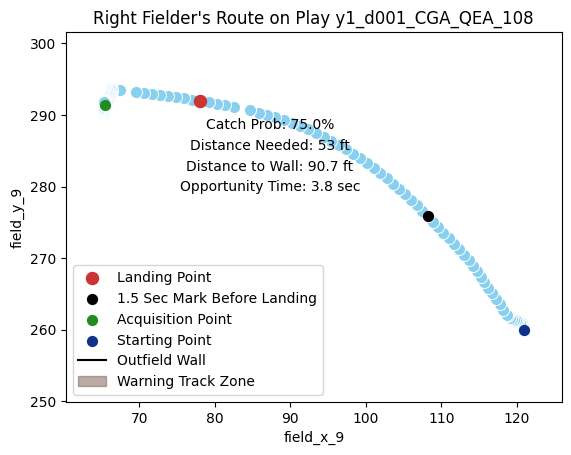

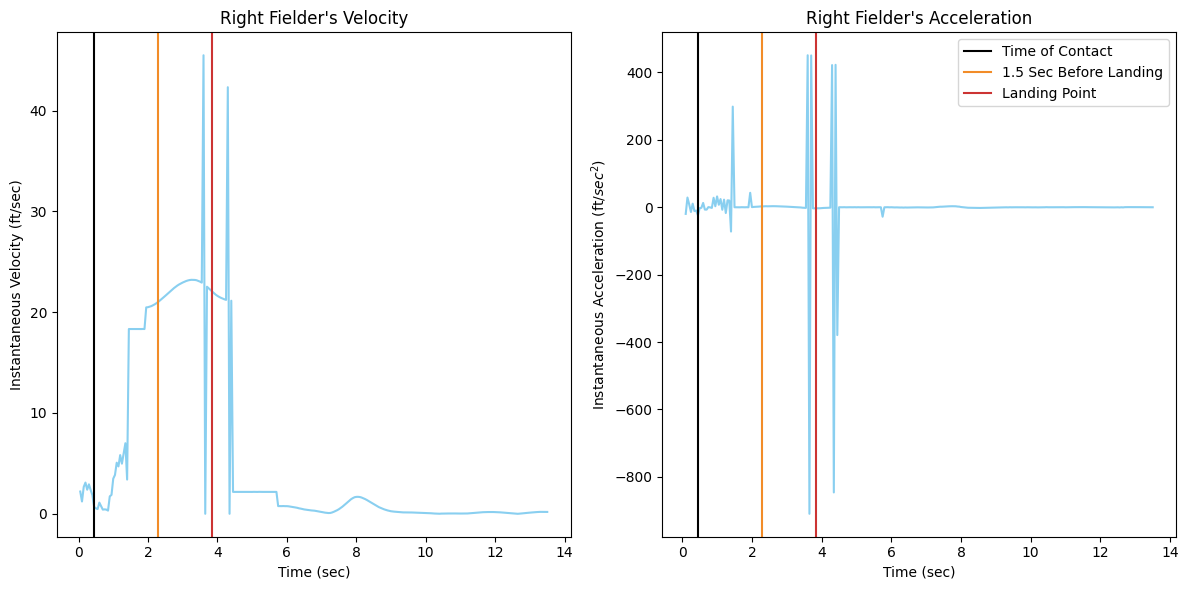

In [118]:
visual_trajectory(aggressive_data, 'y1_d001_CGA_QEA_108')

UnboundLocalError: local variable 'player_pos' referenced before assignment

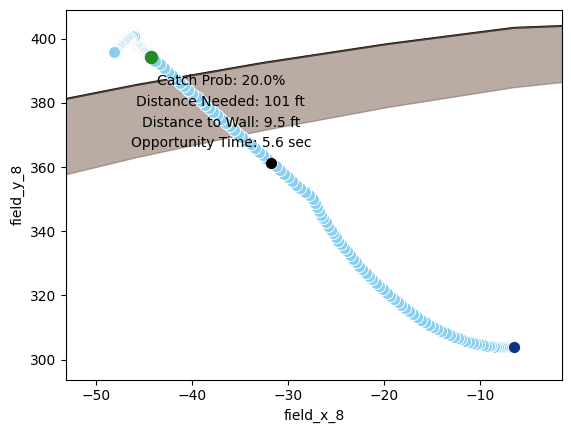

In [119]:
visual_trajectory(aggressive_data, 'y1_d027_JIL_RZQ_160')

### Distance to Closest Teammate

In [908]:
## adding the closest teammate metrics to play_data_w_catch_probs
direction_closest_teammate_dict = metric_into_dict(aggressive_data, direction_closest_teammate)
dist_closest_teammate_dict = metric_into_dict(aggressive_data, dist_closest_teammate)
closest_teammate_dict = metric_into_dict(aggressive_data, closest_teammate)

direction_closest_teammate_df = pd.DataFrame.from_dict(direction_closest_teammate_dict, orient='index', columns=['direction_closest']).reset_index(names=['game_str_id']).copy()
dist_closest_teammate_df = pd.DataFrame.from_dict(dist_closest_teammate_dict, orient='index', columns=['dist_closest']).reset_index(names=['game_str_id']).copy()
closest_teammate_df = pd.DataFrame.from_dict(closest_teammate_dict, orient='index', columns=['closest_pos']).reset_index(names=['game_str_id']).copy()

play_data_w_catch_probs = play_data_w_catch_probs.merge(direction_closest_teammate_df, on='game_str_id', how='left').copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(dist_closest_teammate_df, on='game_str_id', how='left').copy()
play_data_w_catch_probs = play_data_w_catch_probs.merge(closest_teammate_df, on='game_str_id', how='left').copy()

### Getting the data ready for the Bayesian Analysis

In [ ]:
# play_data_w_catch_probs.to_csv('data_w_aggression.csv')

In [22]:
bayesian_data = pd.read_csv('jump_data.csv').iloc[:, 1:].copy()

In [23]:
## finds each component of Jump and compares it to the expectation for that component (what the average player would do)
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_reaction').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_burst').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'expected_route').copy()

bayesian_data.loc[:, 'reaction_vs_avg'] = bayesian_data['reaction'] - bayesian_data['expected_reaction']
bayesian_data.loc[:, 'burst_vs_avg'] = bayesian_data['burst'] - bayesian_data['expected_burst']
bayesian_data.loc[:, 'route_vs_avg'] = bayesian_data['route'] - bayesian_data['expected_route']
bayesian_data.loc[:, 'jump'] = bayesian_data['reaction_vs_avg'] + bayesian_data['burst_vs_avg'] + bayesian_data['route_vs_avg']

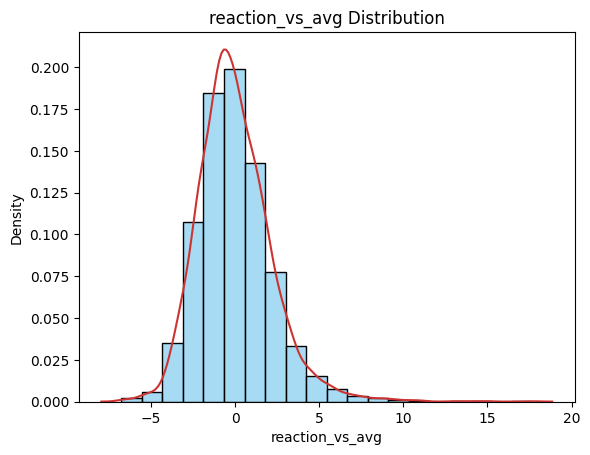

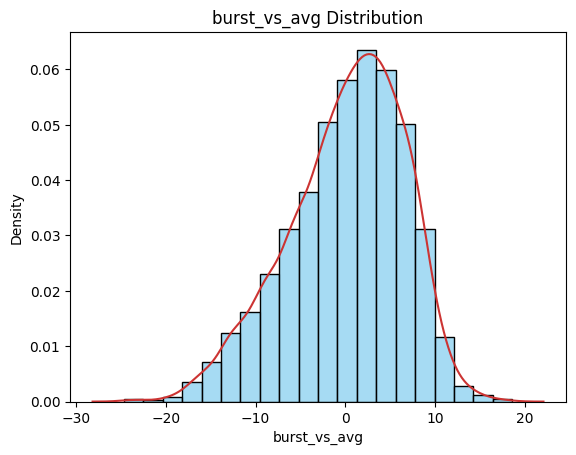

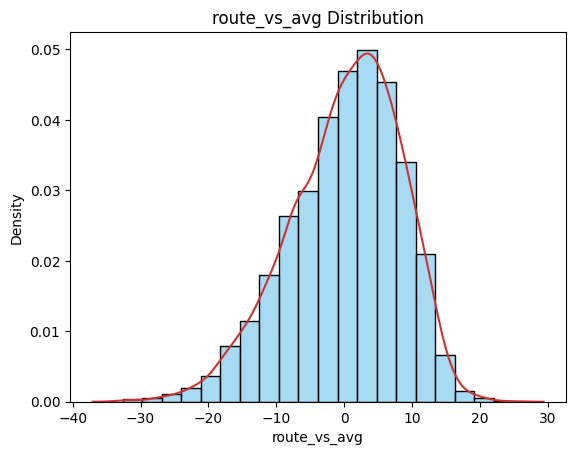

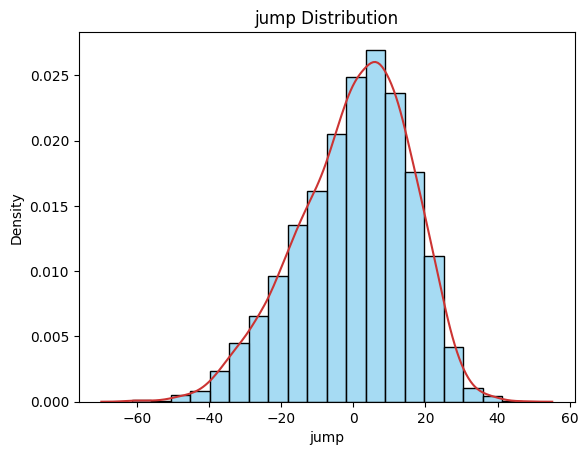

In [23]:
jump_hists(bayesian_data, 'reaction_vs_avg')
jump_hists(bayesian_data, 'burst_vs_avg')
jump_hists(bayesian_data, 'route_vs_avg')
jump_hists(bayesian_data, 'jump')

In [24]:
def agg_attempt_hist(df: pd.DataFrame, column: str) -> None:
    """
    Displays overlapping histograms between aggressive attempts and not for some column
    
    Arguments: column: is some quantitative column in df
    """
    df = df.copy()

    plt.figure(figsize=(8, 4))
    plt.hist(df[df['aggressive_attempt'] == 0][column], bins=25, alpha=0.7, label='Aggressive Attempt == 0', color='#CC3433', density=True)
    plt.hist(df[df['aggressive_attempt'] == 1][column], bins=25, alpha=0.7, label='Aggressive Attempt == 1', color='#89CFF0', density=True)
    plt.xlabel(f"{column.replace('_', ' ')}")
    plt.ylabel('Density')
    plt.title(f"{column.replace('_', ' ')} Comparison Between Aggressive Plays and Not")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

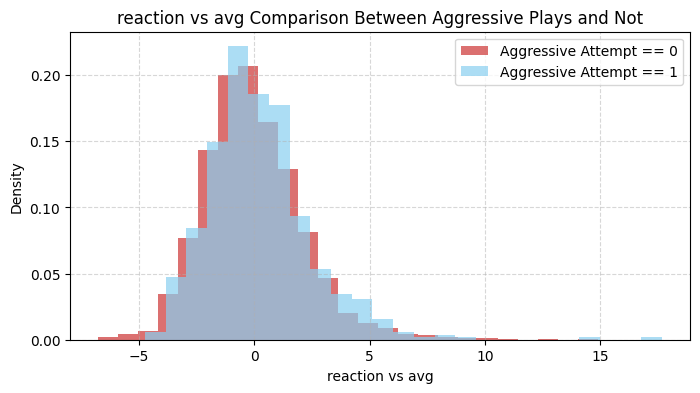

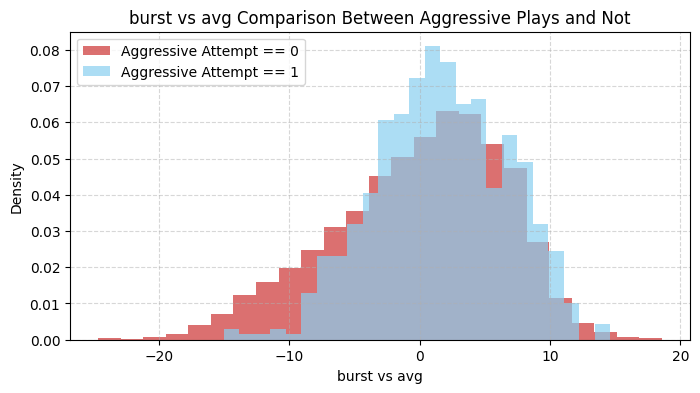

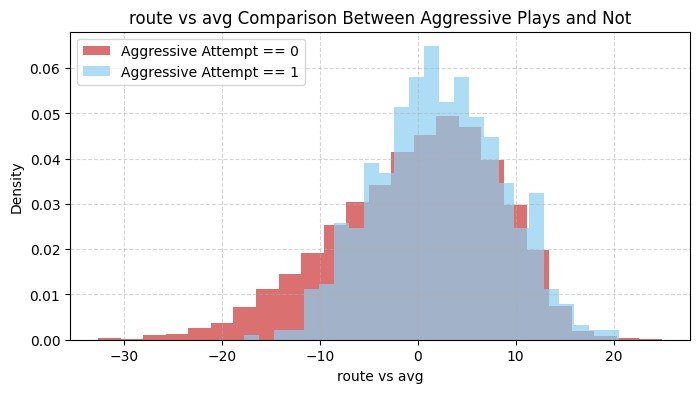

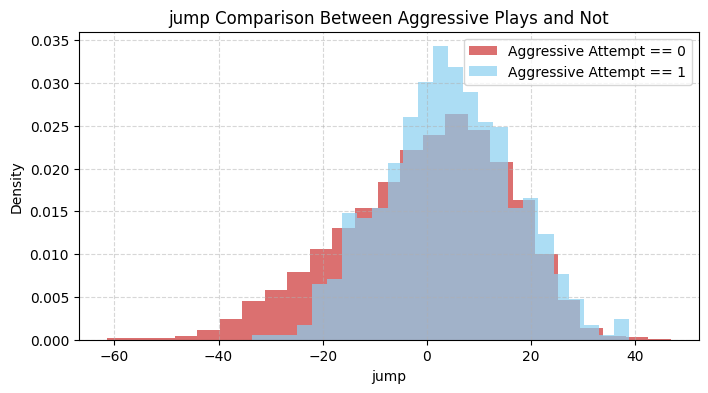

In [25]:
agg_attempt_hist(bayesian_data, 'reaction_vs_avg')
agg_attempt_hist(bayesian_data, 'burst_vs_avg')
agg_attempt_hist(bayesian_data, 'route_vs_avg')
agg_attempt_hist(bayesian_data, 'jump')

In [121]:
# plt.figure()
# sns.kdeplot(data=aggressive_data, x="field_x_7", y="field_y_7", fill=True, cmap="viridis", levels=10)
# sns.kdeplot(data=aggressive_data, x="field_x_8", y="field_y_8", fill=True, cmap="plasma", levels=10)
# sns.kdeplot(data=aggressive_data, x="field_x_9", y="field_y_9", fill=True, cmap="magma", levels=10)
# plt.title("Density Plot of OF Movement")
# plt.xlabel("field_x")
# plt.ylabel("field_y")
# plt.xlim(-300, 300)
# plt.ylim(50, 420)
# plt.show()

### Player Dictionaries

In [24]:
def player_metric_dict(df: pd.DataFrame, pos: str):
    """
    Creates a dictionary for pos that calculates several metrics for every player in that pos

    Arguments: df: Dataframe, pos: position name (left_field, center_field, right_field)
    """
    if pos == 'left_field':
        pos_code = 7
    if pos == 'center_field':
        pos_code = 8
    if pos == 'right_field':
        pos_code = 9

    pos_dict = {}
    for i in df[pos].unique():
        df_player = df[df[pos] == i]
        df_attempt = df_player[df_player['player_attempt'] == pos_code]
        pos_dict[i] = {'metrics': 
                        {'pos': pos_code,
                            'appearances': df_player.shape[0],
                            'max_speed': df_player['sprint_speed'].max(),
                            'total_attempts': df_attempt.shape[0],
                            'agg_attempts': df_attempt['aggressive_attempt'].sum(),
                            'agg_successes': df_attempt[df_attempt['is_out_catch'] == 1]['aggressive_attempt'].sum(),
                            'catch%': df_attempt['is_out_catch'].mean(),
                            'catches_made': df_attempt['is_out_catch'].sum(),
                            'oaa': round((df_attempt['is_out_catch'] - df_attempt['p_catch']).sum(), 1),

                            # 'reaction': df_attempt['reaction_vs_avg'].mean(),
                            # 'burst': df_attempt['burst_vs_avg'].mean(),
                            # 'route': df_attempt['route_vs_avg'].mean(),
                            # 'jump': df_attempt['reaction_vs_avg'].mean() + df_attempt['burst_vs_avg'].mean() + df_attempt['route_vs_avg'].mean(),

                            '5_star_opps': df_attempt[df_attempt['difficulty_level'] == '5 Star'].shape[0],
                            '5_star_successes': df_attempt[df_attempt['difficulty_level'] == '5 Star']['is_out_catch'].sum(),
                            '5_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '5 Star']['aggressive_attempt'].sum(),
                            '5_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '5 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '4_star_opps': df_attempt[df_attempt['difficulty_level'] == '4 Star'].shape[0],
                            '4_star_successes': df_attempt[df_attempt['difficulty_level'] == '4 Star']['is_out_catch'].sum(),
                            '4_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '4 Star']['aggressive_attempt'].sum(),
                            '4_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '4 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),
                            
                            '3_star_opps': df_attempt[df_attempt['difficulty_level'] == '3 Star'].shape[0],
                            '3_star_successes': df_attempt[df_attempt['difficulty_level'] == '3 Star']['is_out_catch'].sum(),
                            '3_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '3 Star']['aggressive_attempt'].sum(),
                            '3_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '3 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '2_star_opps': df_attempt[df_attempt['difficulty_level'] == '2 Star'].shape[0],
                            '2_star_successes': df_attempt[df_attempt['difficulty_level'] == '2 Star']['is_out_catch'].sum(),

                            '1_star_opps': df_attempt[df_attempt['difficulty_level'] == '1 Star'].shape[0],
                            '1_star_successes': df_attempt[df_attempt['difficulty_level'] == '1 Star']['is_out_catch'].sum(),
                        }
                    }
    return pos_dict

In [25]:
left_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'left_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

center_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'center_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

right_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'right_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

all_players = (pd.concat([left_field_players, center_field_players, right_field_players])
               .sort_values(by='agg_attempts', ascending=False)
               .reset_index(drop=True)
               .copy()
               )

### Teammate's Speed

In [29]:
def teammate_speed(df: pd.DataFrame, game_str_id: str):
    """
    
    Arguments: df: Dataframe, game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    closest_teammate_code = closest_teammate(df, game_str_id)
    if closest_teammate_code == 7:
        teammate_pos_name = 'left_field'
    if closest_teammate_code == 8:
        teammate_pos_name = 'center_field'
    if closest_teammate_code == 9:
        teammate_pos_name = 'right_field'

    teammate_name = bayesian_data[bayesian_data['game_str_id'] == game_str_id][teammate_pos_name].iloc[0]
    teammate_max_speed = all_players[all_players['player_name'] == teammate_name]['max_speed'].max()
    teammate_speed = bayesian_data[bayesian_data['game_str_id'] == game_str_id][f'sprint_speed_{int(closest_teammate_code)}'].iloc[0]

    return teammate_speed / teammate_max_speed

In [30]:
## adding the closest teammate metrics to play_data_w_catch_probs
closest_teammate_speed_dict = metric_into_dict(aggressive_data, teammate_speed)
closest_teammate_speed_df = pd.DataFrame.from_dict(closest_teammate_speed_dict, orient='index', columns=['speed_closest']).reset_index(names=['game_str_id']).copy()
bayesian_data = bayesian_data.merge(closest_teammate_speed_df, on='game_str_id', how='left').copy()

### Out-of-Zone Index

In [32]:
def player_metric_dict(df: pd.DataFrame, pos: str):
    """
    Creates a dictionary for pos that calculates several metrics for every player in that pos

    Arguments: df: Dataframe, pos: position name (left_field, center_field, right_field)
    """
    if pos == 'left_field':
        pos_code = 7
    if pos == 'center_field':
        pos_code = 8
    if pos == 'right_field':
        pos_code = 9

    pos_dict = {}
    for i in df[pos].unique():
        df_player = df[df[pos] == i]
        df_attempt = df_player[df_player['player_attempt'] == pos_code]
        pos_dict[i] = {'metrics': 
                        {'pos': pos_code,
                            'appearances': df_player.shape[0],
                            'max_speed': df_player['sprint_speed'].max(),
                            'total_attempts': df_attempt.shape[0],
                            'agg_attempts': df_attempt['aggressive_attempt'].sum(),
                            'agg_successes': df_attempt[df_attempt['is_out_catch'] == 1]['aggressive_attempt'].sum(),
                            'catch%': df_attempt['is_out_catch'].mean(),
                            'oaa': round((df_attempt['is_out_catch'] - df_attempt['p_catch']).sum(), 1),

                            # 'reaction': df_attempt['reaction_vs_avg'].mean(),
                            # 'burst': df_attempt['burst_vs_avg'].mean(),
                            # 'route': df_attempt['route_vs_avg'].mean(),
                            # 'jump': df_attempt['reaction_vs_avg'].mean() + df_attempt['burst_vs_avg'].mean() + df_attempt['route_vs_avg'].mean(),

                            '5_star_opps': df_attempt[df_attempt['difficulty_level'] == '5 Star'].shape[0],
                            '5_star_successes': df_attempt[df_attempt['difficulty_level'] == '5 Star']['is_out_catch'].sum(),
                            '5_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '5 Star']['aggressive_attempt'].sum(),
                            '5_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '5 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '4_star_opps': df_attempt[df_attempt['difficulty_level'] == '4 Star'].shape[0],
                            '4_star_successes': df_attempt[df_attempt['difficulty_level'] == '4 Star']['is_out_catch'].sum(),
                            '4_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '4 Star']['aggressive_attempt'].sum(),
                            '4_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '4 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),
                            
                            '3_star_opps': df_attempt[df_attempt['difficulty_level'] == '3 Star'].shape[0],
                            '3_star_successes': df_attempt[df_attempt['difficulty_level'] == '3 Star']['is_out_catch'].sum(),
                            '3_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '3 Star']['aggressive_attempt'].sum(),
                            '3_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '3 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '2_star_opps': df_attempt[df_attempt['difficulty_level'] == '2 Star'].shape[0],
                            '2_star_successes': df_attempt[df_attempt['difficulty_level'] == '2 Star']['is_out_catch'].sum(),

                            '1_star_opps': df_attempt[df_attempt['difficulty_level'] == '1 Star'].shape[0],
                            '1_star_successes': df_attempt[df_attempt['difficulty_level'] == '1 Star']['is_out_catch'].sum(),
                        }
                    }
    return pos_dict

In [89]:
def filters_data_points(df: pd.DataFrame, game_str_id: str) -> pd.DataFrame:
    """
    Filters the data to be from the point of the pitch to the landing point --> ignoring what happens after the ball lands (can be a catch/bounce/deflection)

    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        if catch_point.shape[0] > 1:
            catch_point = catch_point.iloc[0]
        else:
            catch_point = catch_point.iloc[0]

    return df.iloc[0: catch_point.name+1]

In [90]:
def out_of_zone(df: pd.DataFrame, game_str_id):
    """
    
    Arguments: df: Dataframe, 
    """
    return df

In [ ]:
first_ball_acquired_moment = aggressive_data[(aggressive_data['event_code'] == 2) & (aggressive_data['player_position'].isin([7, 8, 9]))].reset_index(drop=True).copy()
first_ball_acquired_moment.loc[:, 'first_time_acquired'] = first_ball_acquired_moment['timestamp']

## in the rare case the outfielders touch the ball 2x (e.g., one of them passed it to their teammate to throw it in if they're not in the proper position, or an error back to the outfield)
## --> this filters the play where the last row in a play is the last time an outfielder touched the ball such as in the cases mentioned previously
first_ball_acquired_moment = first_ball_acquired_moment.drop_duplicates(subset=['game_str_id'], keep='last').copy()
first_ball_acquired_moment = first_ball_acquired_moment[['game_str_id', 'first_time_acquired']].copy()

## filters the data to the point where the ball is first picked up
out_zone_data = aggressive_data.merge(first_ball_acquired_moment, on='game_str_id', how='left').copy()
out_zone_data = out_zone_data[out_zone_data['timestamp'] <= out_zone_data['first_time_acquired']].reset_index(drop=True).copy()

filtered_dfs = [] 
for i in out_zone_data['game_str_id'].unique():
    filtered_df = filters_data_points(out_zone_data, i)
    filtered_dfs.append(filtered_df) 
filtered_out_zone = pd.concat(filtered_dfs, ignore_index=True)
filtered_out_zone = filtered_out_zone.merge(bayesian_data[['game_str_id', 'player_attempt_id', 'player_attempt']], on='game_str_id', how='left').copy()

In [92]:
filtered_out_zone

,game_str_id,timestamp,at_bat,play_per_game,player_position,player_position_name,event_code,event_code_name,field_x_7,field_y_7,field_x_8,field_y_8,field_x_9,field_y_9,ball_position_x,ball_position_y,ball_position_z,home_team,away_team,year,day,timestamp_diff,elapsed_timestamp,first_time_acquired,player_attempt_id,player_attempt
0,y1_d001_CGA_QEA_4,83.599,2,4.0,1.0,pitcher,1.0,pitch,-133.3230,230.9340,-32.4459,288.7827,96.0153,262.4820,-1.573368,54.88170,5.69139,QEA,CGA,year_1,day_001,0.00,0.00,86.799,QEA-0249,7.0
1,y1_d001_CGA_QEA_4,83.649,NaN,NaN,NaN,NaN,NaN,NaN,-133.3344,230.9436,-32.4774,288.7269,96.0027,262.4826,-1.348383,48.44760,5.48709,NaN,NaN,NaN,NaN,0.05,0.05,86.799,QEA-0249,7.0
2,y1_d001_CGA_QEA_4,83.699,NaN,NaN,NaN,NaN,NaN,NaN,-133.3488,230.9529,-32.5086,288.6756,95.9871,262.4850,-1.138191,42.06180,5.23302,NaN,NaN,NaN,NaN,0.05,0.10,86.799,QEA-0249,7.0
3,y1_d001_CGA_QEA_4,83.749,NaN,NaN,NaN,NaN,NaN,NaN,-133.3656,230.9622,-32.5386,288.6294,95.9688,262.4889,-0.942786,35.72490,4.92924,NaN,NaN,NaN,NaN,0.05,0.15,86.799,QEA-0249,7.0
4,y1_d001_CGA_QEA_4,83.799,NaN,NaN,NaN,NaN,NaN,NaN,-133.3851,230.9706,-32.5665,288.5883,95.9475,262.4937,-0.762171,29.43678,4.57575,NaN,NaN,NaN,NaN,0.05,0.20,86.799,QEA-0249,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504847,y2_d098_YJD_RZQ_259,9633.863,NaN,NaN,NaN,NaN,NaN,NaN,-180.8274,221.5458,-53.3688,294.0177,102.4311,260.8992,-170.340600,212.26800,14.98851,NaN,NaN,NaN,NaN,0.05,3.75,9634.063,YJD-0185,7.0
504848,y2_d098_YJD_RZQ_259,9633.913,NaN,NaN,NaN,NaN,NaN,NaN,-181.5996,221.6478,-53.8113,293.6223,102.2526,260.7810,-172.728300,214.14030,13.04403,NaN,NaN,NaN,NaN,0.05,3.80,9634.063,YJD-0185,7.0
504849,y2_d098_YJD_RZQ_259,9633.963,NaN,NaN,NaN,NaN,NaN,NaN,-182.3721,221.7498,-54.2520,293.2233,102.0735,260.6619,-175.111500,215.97510,11.03643,NaN,NaN,NaN,NaN,0.05,3.85,9634.063,YJD-0185,7.0
504850,y2_d098_YJD_RZQ_259,9634.013,NaN,NaN,NaN,NaN,NaN,NaN,-183.1443,221.8518,-54.6918,292.8210,101.8938,260.5422,-177.490500,217.77210,8.96571,NaN,NaN,NaN,NaN,0.05,3.90,9634.063,YJD-0185,7.0


### Speed at Catch

In [139]:
def speed_at_catch(df: pd.DataFrame, game_str_id: str) -> float:
    """
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    
    if 0.001 in round(df['timestamp_diff'], 3).values:
        for i in ['field_x_7', 'field_y_7', 'field_x_8', 'field_y_8', 'field_x_9', 'field_y_9', 'ball_position_x', 'ball_position_y', 'ball_position_z']:
            df[i] = np.where(df[i].isna(), 
                             df[i].shift(-1),
                             df[i]
                             )
        df.loc[:, 'timestamp_diff'] = np.where(round(df['timestamp_diff'].shift(1), 3) == 0.001, 
                                            df['timestamp_diff'] + 0.001, 
                                            df['timestamp_diff']
                                            )
        df = df[round(df['timestamp_diff'], 3) != 0.001].reset_index(drop=True).copy()

    ## calculates catch point (whether or not the catch point is first bounce or a catch or a deflection)
    idx_dict = {}
    idx_dict[2] = df.index[df['event_code'] == 2][0]
    if (len(df[df['event_code'] == 16])) >= 1:
        idx_dict[16] = df.index[df['event_code'] == 16][0]

    if (len(df[df['event_code'] == 9])) >= 1:
        idx_dict[9] = df.index[df['event_code'] == 9][0]

    if (len(df[df['event_code'] == 10]) >= 1):
        idx_dict[10] = df.index[df['event_code'] == 10][0]

    idx_dict = sorted(idx_dict, key=idx_dict.get)

    if (idx_dict[0] == 2):
        catch_point = df.loc[(df['event_code'] == idx_dict[0]) & (df['player_position'].isin([7, 8, 9]))]
        catch_point = catch_point.iloc[0]
    else:
        catch_point = df.loc[(df['event_code'] == idx_dict[0])]
        catch_point = catch_point.iloc[0]

    ## gives credit it to either who caught or it or was nearest
    if (catch_point['event_code'] == 2) or (catch_point['event_code'] == 9):
        nearest_to_catch_pt = int(catch_point['player_position'])
    else:
        nearest_to_catch_pt = catch_point['player_position']
        nearest_to_catch_pt = {'7': euclidean_distance(catch_point['field_x_7'], catch_point['field_y_7'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '8': euclidean_distance(catch_point['field_x_8'], catch_point['field_y_8'], catch_point['ball_position_x'], catch_point['ball_position_y']),
                            '9': euclidean_distance(catch_point['field_x_9'], catch_point['field_y_9'], catch_point['ball_position_x'], catch_point['ball_position_y'])
                            }
        nearest_to_catch_pt = int(sorted(nearest_to_catch_pt, key=nearest_to_catch_pt.get)[0])

    df = stepwise_dist_func(df, 7).copy()
    df = stepwise_dist_func(df, 8).copy()
    df = stepwise_dist_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_velo_7'] = df['stepwise_dist_7'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_8'] = df['stepwise_dist_8'] / df['timestamp_diff']#.iloc[1:]
    df.loc[:, 'instantaneous_velo_9'] = df['stepwise_dist_9'] / df['timestamp_diff']#.iloc[1:]

    df = delta_velo_func(df, 7).copy()
    df = delta_velo_func(df, 8).copy()
    df = delta_velo_func(df, 9).copy()
    
    df.loc[:, 'instantaneous_acc_7'] = df['delta_velo_7'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_8'] = df['delta_velo_8'] / df['timestamp_diff']#.iloc[2:]
    df.loc[:, 'instantaneous_acc_9'] = df['delta_velo_9'] / df['timestamp_diff']#.iloc[2:]

    ## looks at the interval around the catch point (1.5 sec before and 0.5 sec after)
    catch_time = catch_point['elapsed_timestamp']
    one_half_s_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time-1.5, 1)]['elapsed_timestamp'] - round(catch_time-1.5, 1)).idxmin()
    ## deals with if the play ends before 0.5 sec
    if df.iloc[-1]['elapsed_timestamp'] < (catch_time+0.5):
        half_s_after_marker = None
    else:
        half_s_after_marker = abs(df.loc[round(df['elapsed_timestamp'], 1) == round(catch_time+0.5, 1)]['elapsed_timestamp'] - round(catch_time+0.5, 1)).idxmin() + 1

    df = df.iloc[one_half_s_marker: half_s_after_marker].reset_index(drop=True).copy()

    ## makes sure the df doesn't contain any infinite values
    df = df[(df['timestamp'] > df['timestamp'].shift(1)) & (~(np.isinf(df['instantaneous_velo_7']) | np.isinf(df['instantaneous_velo_8']) | np.isinf(df['instantaneous_velo_9'])))].copy()

    lf_speed_catch = df['stepwise_dist_7'].sum() / (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0])
    cf_speed_catch = df['stepwise_dist_8'].sum() / (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0])
    rf_speed_catch = df['stepwise_dist_9'].sum() / (df['timestamp'].iloc[-1] - df['timestamp'].iloc[0])

    return np.array([lf_speed_catch, cf_speed_catch, rf_speed_catch])

In [159]:
speed_at_catch_dict = metric_into_dict(aggressive_data, speed_at_catch)
speed_at_catch_df = pd.DataFrame.from_dict(speed_at_catch_dict, orient='index', columns=['speed_catch_7', 'speed_catch_8', 'speed_catch_9']).reset_index(names=['game_str_id']).copy()
bayesian_data = bayesian_data.merge(speed_at_catch_df, on='game_str_id', how='left').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'speed_catch').copy()

### Speed Needed

In [149]:
def speed_needed(df: pd.DataFrame, game_str_id: str):
    """
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()

    ## average speed needed
    return distance_needed(df, game_str_id) / opportunity_time(df, game_str_id)

In [160]:
speed_needed_dict = metric_into_dict(aggressive_data, speed_needed)
speed_needed_df = pd.DataFrame.from_dict(speed_needed_dict, orient='index', columns=['speed_needed_7', 'speed_needed_8', 'speed_needed_9']).reset_index(names=['game_str_id']).copy()
bayesian_data = bayesian_data.merge(speed_needed_df, on='game_str_id', how='left').copy()
bayesian_data = attempt_metric_creator(bayesian_data, 'speed_needed').copy()

### Bayesian Analysis

#### More prep

In [ ]:
# bayesian_data.to_csv('bayesian_data.csv')
# bayesian_data = pd.read_csv('bayesian_data.csv').iloc[:, 1:].copy()

In [26]:
## takes the player's stats for their primary position
pos_player_stats = all_players.groupby('player_name').agg({'appearances': 'sum',
                                        'max_speed': 'max',
                                        'total_attempts': 'sum',
                                        'catches_made': 'sum',
                                        'agg_attempts': 'sum',
                                        'agg_successes': 'sum',
                                        '5_star_opps': 'sum',
                                        '5_star_successes': 'sum',
                                        '5_Star_agg_attempts': 'sum',
                                        '5_star_agg_successes': 'sum',
                                        '4_star_opps': 'sum',
                                        '4_star_successes': 'sum',
                                        '4_Star_agg_attempts': 'sum',
                                        '4_star_agg_successes': 'sum',
                                        '3_star_opps': 'sum',
                                        '3_star_successes': 'sum',
                                        '3_Star_agg_attempts': 'sum',
                                        '3_star_agg_successes': 'sum',
                                        '2_star_opps': 'sum',
                                        '2_star_successes': 'sum',
                                        '1_star_opps': 'sum',
                                        '1_star_successes': 'sum',
                                        }).sort_values(by='agg_attempts', ascending=False).reset_index().copy()


primary_pos = all_players.sort_values('appearances', ascending=False).drop_duplicates('player_name')[['player_name', 'pos', 'oaa']].copy()
primary_pos_player_stats = primary_pos.merge(pos_player_stats, on='player_name')

In [27]:
def agg_attempt_hist(df: pd.DataFrame, column: str) -> None:
    """
    Displays overlapping histograms between aggressive attempts and not for some column
    
    Arguments: column: is some quantitative column in df
    """
    df = df.copy()

    plt.figure(figsize=(8, 4))
    plt.hist(df[df['aggressive_attempt'] == 0][column], bins=25, alpha=0.7, label='Aggressive Attempt == 0', color='#CC3433', density=True)
    plt.hist(df[df['aggressive_attempt'] == 1][column], bins=25, alpha=0.7, label='Aggressive Attempt == 1', color='#89CFF0', density=True)
    plt.xlabel(f"{column.replace('_', ' ')}")
    plt.ylabel('Density')
    plt.title(f"{column.replace('_', ' ')} Comparison Between Aggressive Plays and Not")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

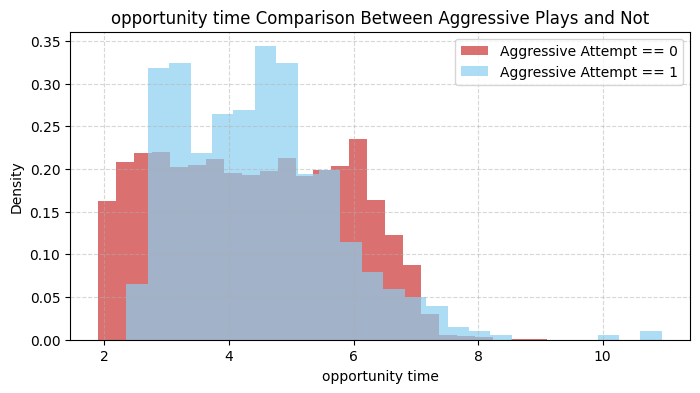

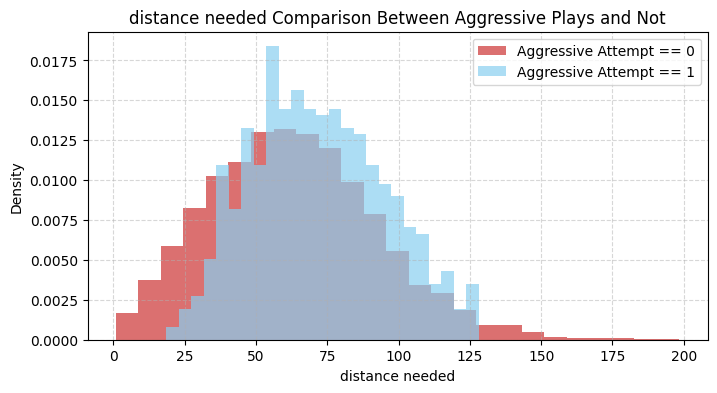

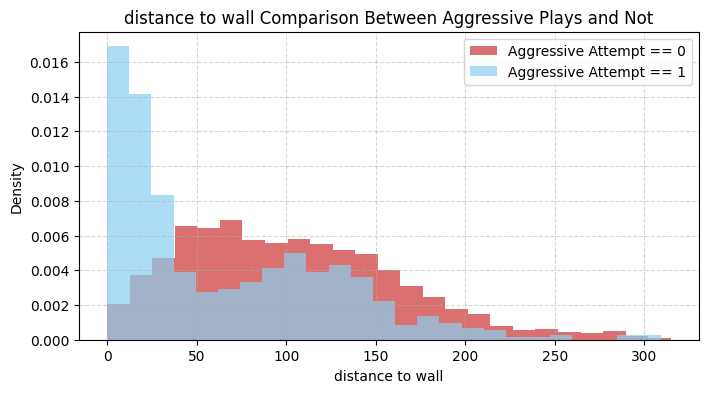

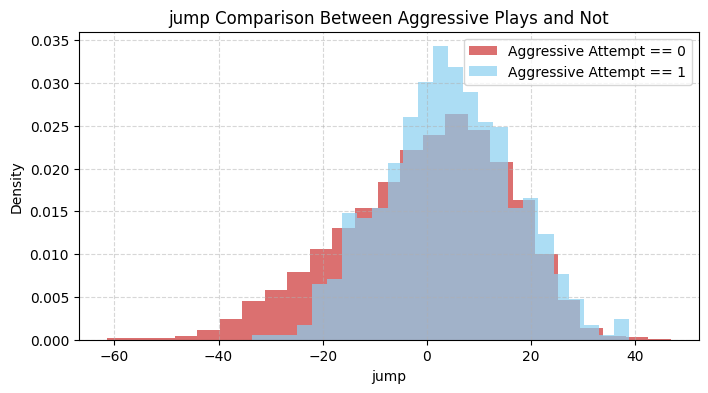

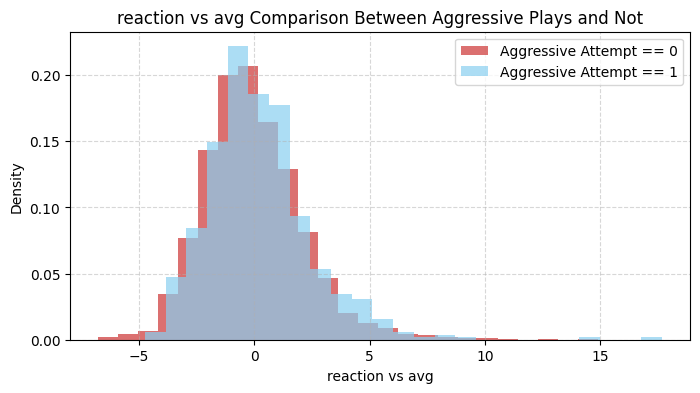

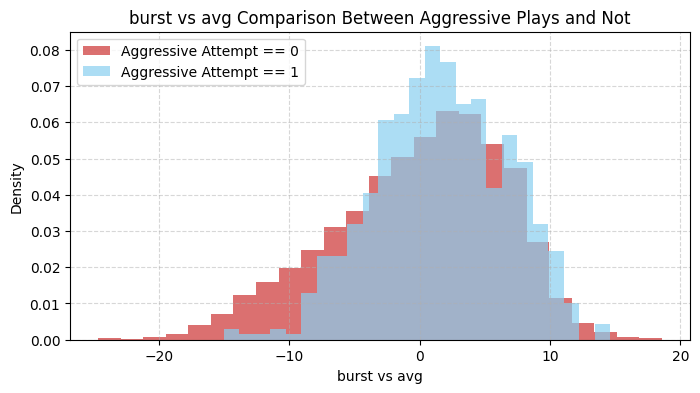

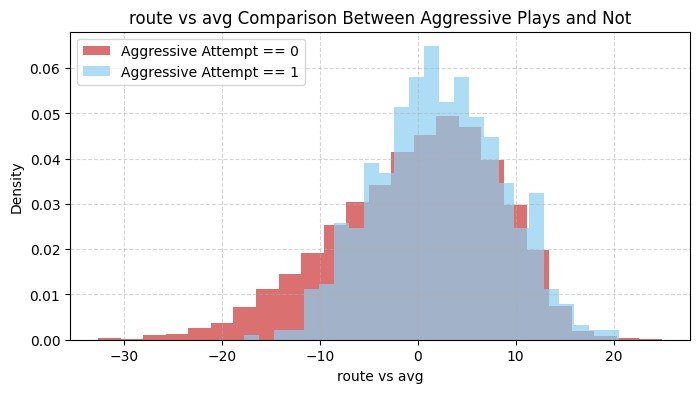

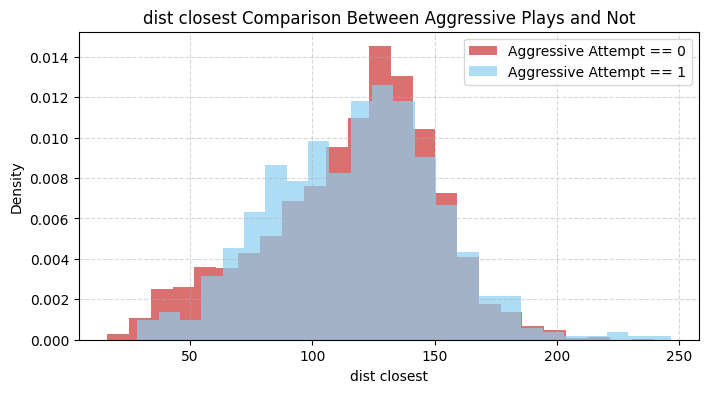

In [145]:
agg_attempt_hist(bayesian_data, 'opportunity_time')
agg_attempt_hist(bayesian_data, 'distance_needed')
agg_attempt_hist(bayesian_data, 'distance_to_wall')
agg_attempt_hist(bayesian_data, 'jump')
agg_attempt_hist(bayesian_data, 'reaction_vs_avg')
agg_attempt_hist(bayesian_data, 'burst_vs_avg')
agg_attempt_hist(bayesian_data, 'route_vs_avg')
agg_attempt_hist(bayesian_data, 'dist_closest')

In [28]:
## filters the data to only include relevant features
filtered_bayesian_data = bayesian_data[['game_str_id', 'aggressive_attempt', 'player_attempt', 'player_attempt_id', 
                               'opportunity_time', 'launch_angle', 'distance_to_wall', 'exit_velo', 'is_out_catch', 
                               'distance_needed', 'direction_angle', 'sprint_speed', 'p_catch', 'difficulty_level',
                               'direction_closest', 'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'route_vs_avg']].copy()
filtered_bayesian_data['player_attempt'] = filtered_bayesian_data['player_attempt'].astype(int)
## makes the player's position who made the attempt on that game_str_id be their primary position (even if they didn't play there)
filtered_bayesian_data = filtered_bayesian_data.merge(primary_pos_player_stats[['player_name', 'pos']], left_on='player_attempt_id', right_on='player_name', how='left').copy()
filtered_bayesian_data = filtered_bayesian_data[['game_str_id', 'aggressive_attempt', 'player_name', 'pos', 
                               'opportunity_time', 'launch_angle', 'distance_to_wall', 'exit_velo', 'is_out_catch', 
                               'distance_needed', 'direction_angle', 'sprint_speed', 'p_catch', 'difficulty_level',
                               'direction_closest', 'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'route_vs_avg',]].copy()
## there's only 7 rows and i'm not going to bother with imputing only a few rows
filtered_bayesian_data = filtered_bayesian_data.dropna(subset=['dist_closest', 'route_vs_avg', 'direction_closest']).reset_index(drop=True).copy()

## prepares the features by encoding/standardizing
play_difficulty_map = {'1 Star': 1, '2 Star': 2, '3 Star': 3, '4 Star': 4, '5 Star': 5}

player_encoder = LabelEncoder().fit(filtered_bayesian_data['player_name'])
pos_encoder = LabelEncoder().fit(filtered_bayesian_data['pos'])
filtered_bayesian_data['player_idx'] = player_encoder.transform(filtered_bayesian_data['player_name'])
filtered_bayesian_data['pos_idx'] = pos_encoder.transform(filtered_bayesian_data['pos'])

filtered_bayesian_data = filtered_bayesian_data[['game_str_id', 'aggressive_attempt', 'player_name', 'player_idx', 'pos', 'pos_idx',
                               'opportunity_time', 'launch_angle', 'distance_to_wall', 'exit_velo',
                               'distance_needed', 'direction_angle',
                               'direction_closest', 'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'route_vs_avg',]].copy()

## encodes the categorical features
filtered_bayesian_data.loc[:, 'direction_cat_code'] = filtered_bayesian_data['direction_angle'].astype('category').cat.codes
filtered_bayesian_data.loc[:, 'teammate_direction_cat_code'] = filtered_bayesian_data['direction_closest'].astype('category').cat.codes

## standardizes the numerical features of the model
num_cols = filtered_bayesian_data[['opportunity_time', 'launch_angle', 'distance_to_wall', 'exit_velo', 'distance_needed', 
                                   'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'route_vs_avg']]
filtered_bayesian_data[num_cols.columns] = scaler.fit_transform(filtered_bayesian_data[num_cols.columns])

#### Modeling

In [29]:
coords = {'player': player_encoder.classes_,
          'pos': pos_encoder.classes_,
          'obs': np.arange(filtered_bayesian_data.shape[0]),
          'features': ['opportunity_time', 'launch_angle', 'distance_to_wall', 'exit_velo', 'distance_needed', 
                       'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'route_vs_avg', 'direction_cat_code', 'teammate_direction_cat_code'
                       ],
          }

player_indices = filtered_bayesian_data['player_idx'].values
pos_indices = filtered_bayesian_data['pos_idx'].values

player_pos_map = (filtered_bayesian_data[['player_idx', 'pos_idx']].drop_duplicates().set_index('player_idx')['pos_idx'].sort_index())
player_pos_idx = player_pos_map.values

X = filtered_bayesian_data[coords['features']].values
y_values = filtered_bayesian_data['aggressive_attempt'].values

In [30]:
pd.DataFrame(X, columns=coords['features']).corr().abs().style.background_gradient()

,opportunity_time,launch_angle,distance_to_wall,exit_velo,distance_needed,dist_closest,reaction_vs_avg,burst_vs_avg,route_vs_avg,direction_cat_code,teammate_direction_cat_code
opportunity_time,1.000000,0.000045,0.448315,0.042042,0.214570,0.446392,0.001305,0.013566,0.012872,0.263473,0.065931
launch_angle,0.000045,1.000000,0.010820,0.086702,0.034333,0.012199,0.004370,0.007847,0.008639,0.019888,0.039074
distance_to_wall,0.448315,0.010820,1.000000,0.406658,0.301400,0.102116,0.005143,0.014716,0.013745,0.473435,0.009430
exit_velo,0.042042,0.086702,0.406658,1.000000,0.097899,0.044679,0.017396,0.242731,0.216444,0.301944,0.153291
distance_needed,0.214570,0.034333,0.301400,0.097899,1.000000,0.132213,0.004703,0.004048,0.002281,0.105470,0.010518
dist_closest,0.446392,0.012199,0.102116,0.044679,0.132213,1.000000,0.017216,0.025504,0.016419,0.278809,0.307906
reaction_vs_avg,0.001305,0.004370,0.005143,0.017396,0.004703,0.017216,1.000000,0.383886,0.479429,0.004336,0.012746
burst_vs_avg,0.013566,0.007847,0.014716,0.242731,0.004048,0.025504,0.383886,1.000000,0.941067,0.001373,0.015681
route_vs_avg,0.012872,0.008639,0.013745,0.216444,0.002281,0.016419,0.479429,0.941067,1.000000,0.003299,0.003009
direction_cat_code,0.263473,0.019888,0.473435,0.301944,0.105470,0.278809,0.004336,0.001373,0.003299,1.000000,0.087145


In [31]:
## dealt with some multicolinearity
new_coords = {'player': player_encoder.classes_,
          'pos': pos_encoder.classes_,
          'obs': np.arange(filtered_bayesian_data.shape[0]),
          'features': ['opportunity_time', 'distance_to_wall', 'exit_velo', 'distance_needed', 
                       'dist_closest', 'reaction_vs_avg', 'burst_vs_avg',
                       'direction_cat_code', 'teammate_direction_cat_code'
                       ],
          }
X = filtered_bayesian_data[new_coords['features']].values

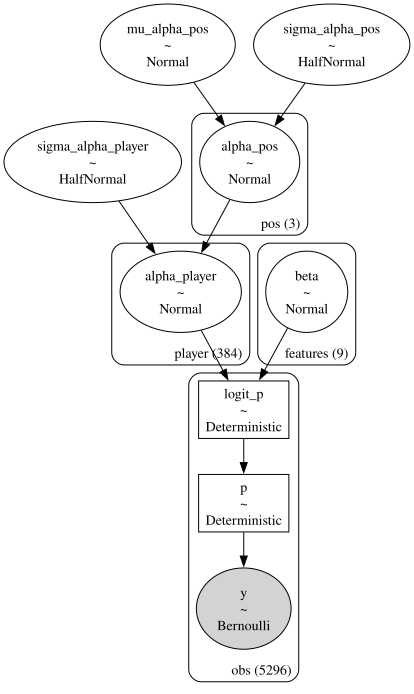

In [33]:
## setting up the hierarchy -> baseline (no parametrization) 
with pm.Model(coords=new_coords) as individual_player_model:

    ## random effects for the groups
    ## pos group level
    mu_alpha_pos = pm.Normal('mu_alpha_pos', mu=0, sigma=1)
    sigma_alpha_pos = pm.HalfNormal('sigma_alpha_pos', sigma=1) 
    alpha_pos = pm.Normal('alpha_pos', mu=mu_alpha_pos, sigma=sigma_alpha_pos, dims='pos')

    ## player group level nested within pos 
    sigma_alpha_player = pm.HalfNormal('sigma_alpha_player', sigma=1)
    alpha_player = pm.Normal('alpha_player', mu=alpha_pos[player_pos_idx], sigma=sigma_alpha_player, dims='player')

    ## fixed effects
    beta = pm.Normal('beta', mu=0, sigma=1, dims='features')

    ## log-odds model
    logit_p = pm.Deterministic('logit_p', alpha_player[player_indices] + beta.dot(X.T), dims='obs')

    ## taking the inverse of the logit (putting it into the 0-1 scale)
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p), dims='obs')

    ## outputs likelihood 
    y = pm.Bernoulli('y', p=p, observed=y_values, dims='obs')

pm.model_to_graphviz(individual_player_model)

In [34]:
with individual_player_model:
    individual_covariate_trace = pm.sample(1_000, tune=2_000, chains=2, nuts_sampler='numpyro', random_seed=RANDOM_SEED)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 230 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: >

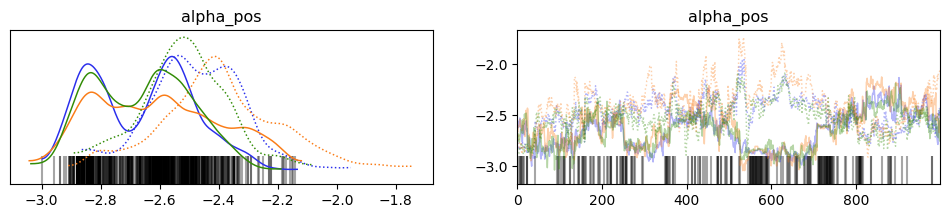

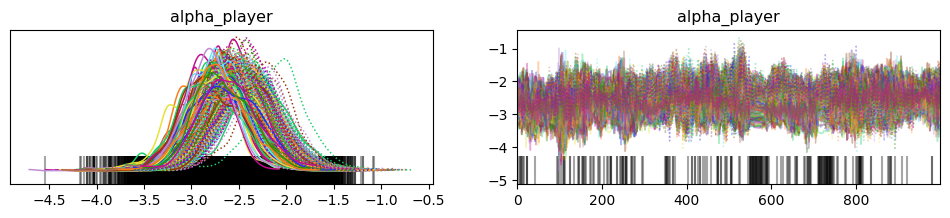

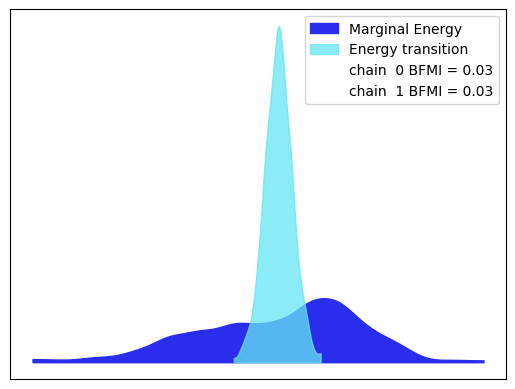

In [35]:
az.plot_trace(individual_covariate_trace, var_names=['alpha_pos'])
az.plot_trace(individual_covariate_trace, var_names=['alpha_player'])
az.plot_energy(individual_covariate_trace)

#### Reparameterization Model

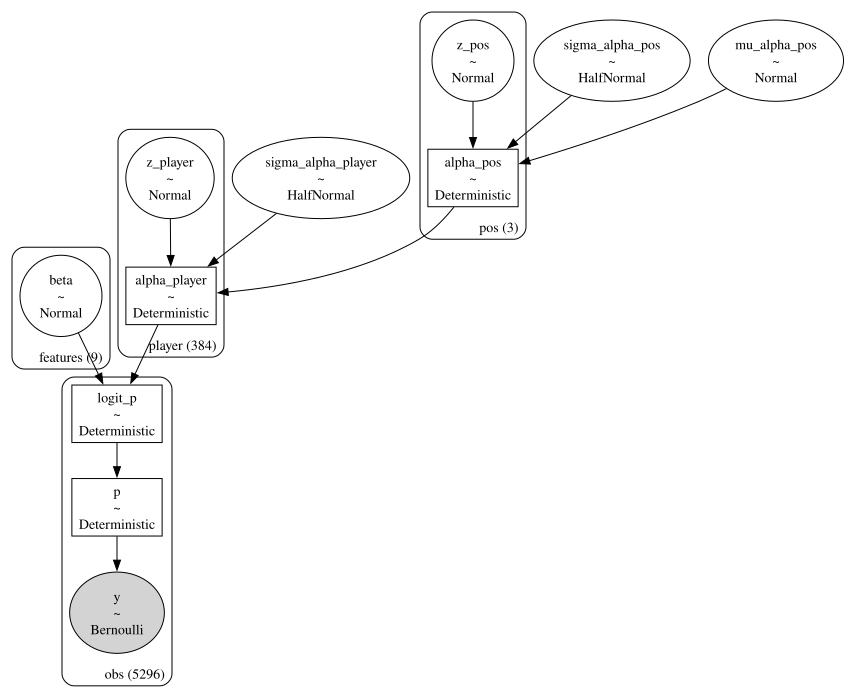

In [32]:
## setting up the hierarchy 
with pm.Model(coords=new_coords) as non_centered_individual_player_model:

    ## random effects for the groups
    ## pos group level
    z_pos = pm.Normal('z_pos', mu=0, sigma=1, dims='pos') ## non-centered parameterization
    sigma_alpha_pos = pm.HalfNormal('sigma_alpha_pos', sigma=1)
    mu_alpha_pos = pm.Normal('mu_alpha_pos', mu=0, sigma=1)
    alpha_pos = pm.Deterministic('alpha_pos', mu_alpha_pos + sigma_alpha_pos * z_pos, dims='pos')

    ## player group level
    z_player = pm.Normal('z_player', mu=0, sigma=1, dims='player') ## non-centered parameterization
    sigma_alpha_player = pm.HalfNormal('sigma_alpha_player', sigma=1)
    alpha_player = pm.Deterministic('alpha_player', alpha_pos[player_pos_idx] + z_player * sigma_alpha_player, dims='player')

    ## fixed effects 
    beta = pm.Normal('beta', mu=0, sigma=1, dims='features')

    ## log-odds model
    logit_p = pm.Deterministic('logit_p', alpha_player[player_indices] + beta.dot(X.T), dims='obs')

    ## taking the inverse of the logit (putting it into the 0-1 scale)
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p), dims='obs')

    ## outputs the likelihood 
    y = pm.Bernoulli('y', p=p, observed=y_values, dims='obs')

pm.model_to_graphviz(non_centered_individual_player_model)

In [33]:
with non_centered_individual_player_model:
    non_centered_individual_player_trace = pm.sample(1000, tune=2000, target_accept=0.99, nuts_sampler='numpyro', random_seed=RANDOM_SEED)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


In [152]:
az.summary(non_centered_individual_player_trace, var_names=['beta'], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[opportunity_time],-0.31,0.07,-0.43,-0.18,0.0,0.0,4930.47,3240.36,1.0
beta[distance_to_wall],-0.85,0.07,-0.99,-0.72,0.0,0.0,4297.45,3187.11,1.0
beta[exit_velo],0.25,0.06,0.13,0.37,0.0,0.0,4803.31,3120.70,1.0
beta[distance_needed],0.57,0.06,0.46,0.67,0.0,0.0,6022.17,2969.86,1.0
beta[dist_closest],0.02,0.06,-0.08,0.13,0.0,0.0,5101.82,2749.75,1.0
beta[reaction_vs_avg],0.01,0.05,-0.09,0.10,0.0,0.0,5863.15,2955.36,1.0
beta[burst_vs_avg],0.48,0.06,0.36,0.60,0.0,0.0,5001.97,3418.88,1.0
beta[direction_cat_code],-0.00,0.03,-0.07,0.06,0.0,0.0,4992.79,3033.96,1.0
beta[teammate_direction_cat_code],0.00,0.04,-0.08,0.08,0.0,0.0,4136.79,2950.20,1.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_player[RZQ-0274],-2.101,0.269,-2.575,-1.568,0.005,0.004,2739.0,2740.0,1.0
alpha_player[YJD-0193],-2.248,0.253,-2.686,-1.749,0.004,0.004,3900.0,3012.0,1.0
alpha_player[RZQ-0275],-2.260,0.290,-2.806,-1.726,0.005,0.005,4160.0,3008.0,1.0
alpha_player[YJD-0106],-2.287,0.331,-2.932,-1.693,0.005,0.006,4252.0,3006.0,1.0
alpha_player[RZQ-0409],-2.298,0.276,-2.814,-1.784,0.005,0.005,3447.0,3140.0,1.0
...,...,...,...,...,...,...,...,...,...
alpha_player[QEA-0235],-2.695,0.303,-3.273,-2.140,0.005,0.005,3820.0,3002.0,1.0
alpha_player[RZQ-0400],-2.702,0.299,-3.231,-2.131,0.004,0.005,4690.0,3121.0,1.0
alpha_player[YJD-0397],-2.704,0.249,-3.195,-2.266,0.004,0.004,4439.0,3394.0,1.0
alpha_player[YJD-0327],-2.712,0.260,-3.214,-2.225,0.004,0.004,4308.0,3211.0,1.0


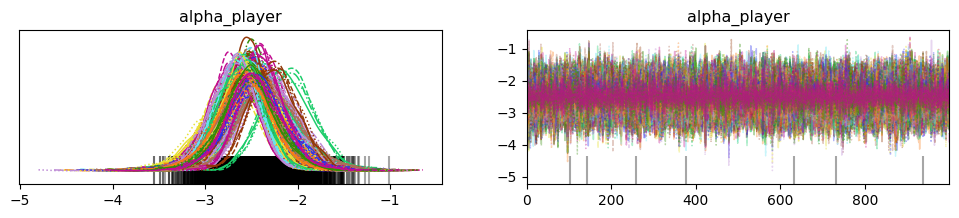

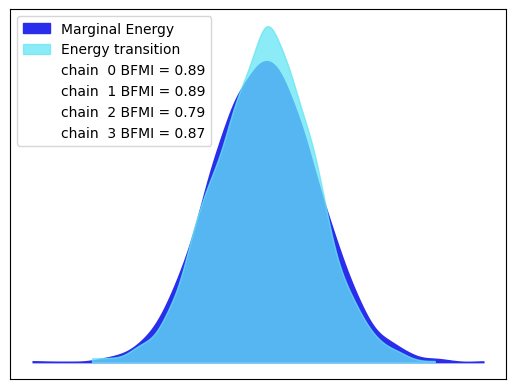

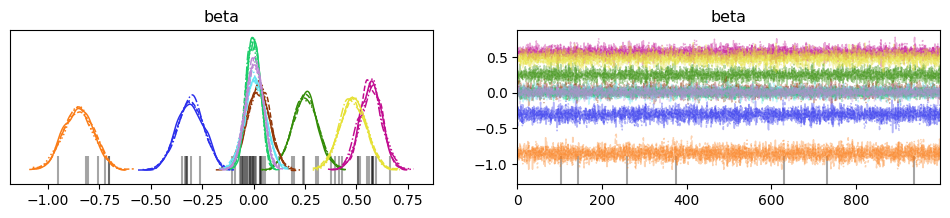

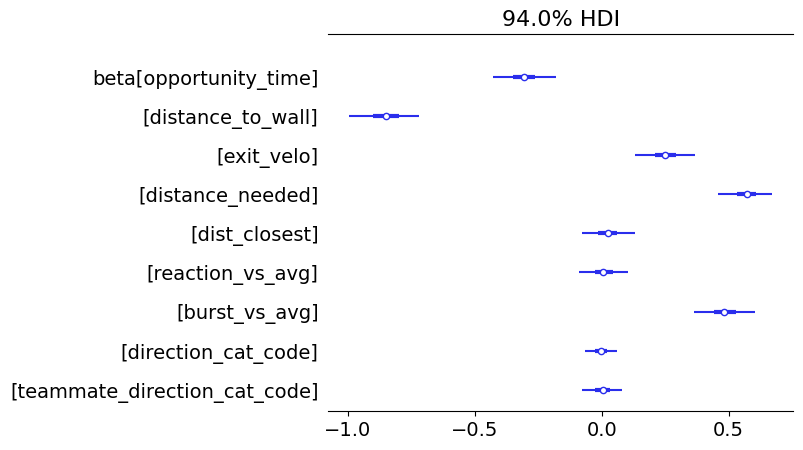

In [ ]:
az.summary(non_centered_individual_player_trace, var_names=['~p', '~logit_p'], round_to=2)
az.plot_trace(non_centered_individual_player_trace, var_names=['alpha_player'])
az.plot_energy(non_centered_individual_player_trace)
az.plot_trace(non_centered_individual_player_trace, var_names=['beta'])
az.summary(non_centered_individual_player_trace, var_names=['beta'], round_to=3)
az.plot_forest(non_centered_individual_player_trace, var_names=["beta"], combined=True, hdi_prob=0.94)
az.summary(non_centered_individual_player_trace, var_names=['alpha_player']).sort_values(by='mean', ascending=False)
az.summary(non_centered_individual_player_trace, var_names=['beta'], round_to=2).sort_values(by='mean', ascending=False)

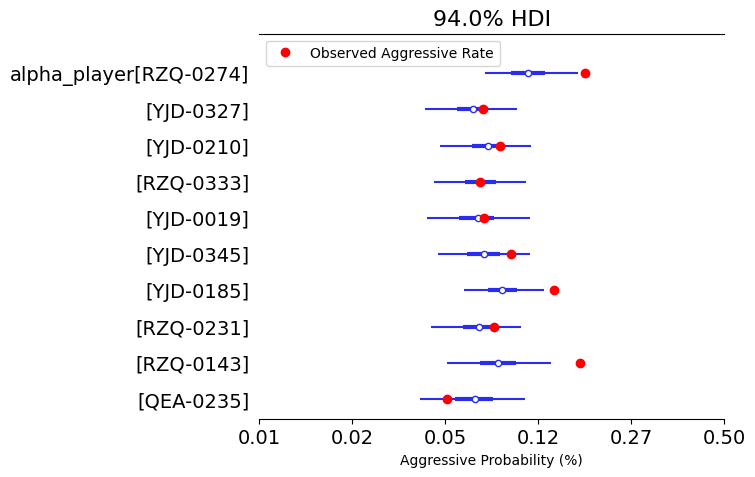

In [148]:
## this needs to be run AFTER the AOE section was ran
selected_players = ['RZQ-0274', 'YJD-0327'] + primary_pos_aoe_players[primary_pos_aoe_players['total_attempts'] > 25]['player_name'].sample(8).to_list()

agg_rates = primary_pos_aoe_players.set_index('player_name').loc[selected_players]['agg_attempt_rate'].values
# agg_rates_scaled = agg_rates / 100
# ax.plot(agg_rates_scaled[::-1], ax.get_yticks(), 'ro')
(ax,) = az.plot_forest(non_centered_individual_player_trace, var_names=["alpha_player"], coords={"player": selected_players}, combined=True)
agg_rates_logit = logit(agg_rates)
ax.plot(agg_rates_logit[::-1], ax.get_yticks(), 'ro', label="Observed Aggressive Rate")
ax.set_xlabel("Aggressive Probability (%)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{logit_to_prob(x):.2f}")) ## changes the log-odds to probability
ax.set_xlim(-5, 0)
ax.legend(loc="upper left")

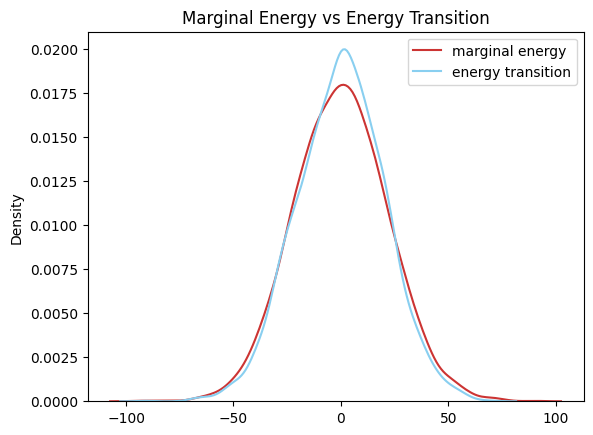

In [35]:
energy = non_centered_individual_player_trace.sample_stats['energy'].values.ravel()
energy_diff = np.diff(energy)
plt.figure()
sns.kdeplot(energy - energy.mean(), label='marginal energy', color=red_color)
sns.kdeplot(energy_diff, label='energy transition', color=baby_blue_color)
plt.legend()
plt.title('Marginal Energy vs Energy Transition')
plt.show()

In [36]:
with non_centered_individual_player_model:
    pm.compute_log_likelihood(non_centered_individual_player_trace)

az.loo(non_centered_individual_player_trace, non_centered_individual_player_model)

Output()

Computed from 4000 posterior samples and 5296 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1623.33    45.41
p_loo       37.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5296  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

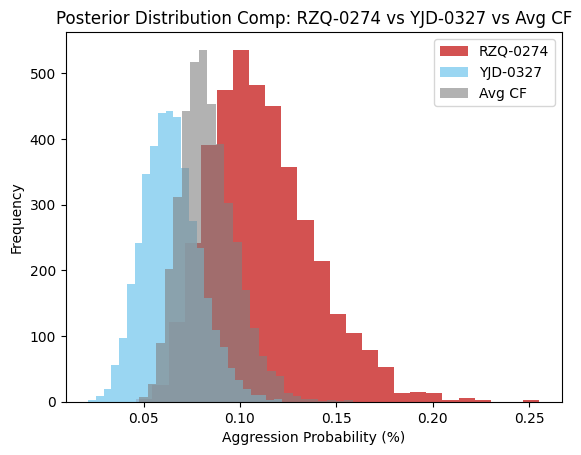

In [ ]:
## this needs to be run AFTER the AOE section was ran
formatter = FuncFormatter(lambda x, _: f"{logit_to_prob(x):.2f}")

posterior_samples = non_centered_individual_player_trace.posterior['alpha_player']
top_guy = posterior_samples.sel(player='RZQ-0274').values.flatten()
bottom_guy = posterior_samples.sel(player='YJD-0397').values.flatten()

## avg cf posterior vals
cf_logodds = non_centered_pos_avg_trace.posterior['alpha_pos'].sel(pos=8).values.flatten()
cf_probs = logit_to_prob(cf_logodds)

plt.figure()
plt.hist(logit_to_prob(top_guy), bins=25, alpha=0.85, label='RZQ-0274', color='#CC3433')
plt.hist(logit_to_prob(bottom_guy), bins=25, alpha=0.85, label='YJD-0327', color='#89CFF0')
plt.hist(cf_probs, bins=25, alpha=0.6, label='Avg CF', color='gray')
plt.xlabel("Aggression Probability (%)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Posterior Distribution Comp: RZQ-0274 vs YJD-0327 vs Avg CF")
# plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [238]:
# with non_centered_individual_player_model:
#     X_data = pm.Data('X_update', X)
#     position_ind = pm.Data('pos_idx_update', pos_indices.astype(int))
#     batter_ind = pm.Data('player_idx_update', player_indices.astype(int))

##### Individual Probability

In [81]:
def individual_prob_metric(df: pd.DataFrame, game_str_id: str):
    """
    Finds the accredited player's aggressive probability in that game_str_id
    Also includes the probability's 94% HDI
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    df = df[['game_str_id', 'player_name', 'player_idx', 'pos', 'pos_idx',
             'opportunity_time', 'distance_to_wall', 'exit_velo', 
             'distance_needed', 'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 
             'direction_cat_code', 'teammate_direction_cat_code']].copy()

    X = df[['opportunity_time', 'distance_to_wall', 'exit_velo', 'distance_needed', 
           'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'direction_cat_code', 
           'teammate_direction_cat_code']].values.flatten()
    
    player_name = df['player_name'].iloc[0]
    player_pos = df['pos'].iloc[0]

    ## gets the posterior samples for that player, his pos, and the beta coefs
    alpha_player = non_centered_individual_player_trace.posterior['alpha_player'].sel(player=player_name).values.flatten()
    betas_mcmc_samples = non_centered_individual_player_trace.posterior['beta'].values
    
    ## reshapes the samples to be in the form: n x d (n obs and d features) instead of: chain num x n x d
    betas_mcmc_samples_flattened = betas_mcmc_samples.reshape(-1, betas_mcmc_samples.shape[-1])
    logit_samples = alpha_player + betas_mcmc_samples_flattened.dot(X.T)

    ## inverses the logit log odd into the sigmoid function (scale of 0 to 1)
    p_samples = 1 / (1 + np.exp(-logit_samples))
    mean_p = np.mean(p_samples)
    hdi = az.hdi(p_samples, hdi_prob=0.94)

    return np.array([mean_p, hdi[0], hdi[1]])

In [82]:
individual_prob_metric(filtered_bayesian_data, 'y1_d001_CGA_QEA_240')

array([0.03804134, 0.01733637, 0.06045624])

In [39]:
individual_prob_metric_dict = metric_into_dict(filtered_bayesian_data, individual_prob_metric)
individual_prob_metric_df = pd.DataFrame.from_dict(individual_prob_metric_dict, orient='index', columns=['indiv_prob', 'prob_hdi_low', 'prob_hdi_high']).reset_index(names=['game_str_id']).copy()
filtered_bayesian_data = filtered_bayesian_data.merge(individual_prob_metric_df, on='game_str_id', how='left').copy()
filtered_bayesian_data.loc[:, 'hdi_range'] = filtered_bayesian_data['prob_hdi_high'] - filtered_bayesian_data['prob_hdi_low']
# filtered_bayesian_data[['indiv_prob', 'prob_hdi_low', 'prob_hdi_high', 'hdi_range']] = filtered_bayesian_data[['indiv_prob', 'prob_hdi_low', 'prob_hdi_high', 'hdi_range']] * 100

#### Position Average Model

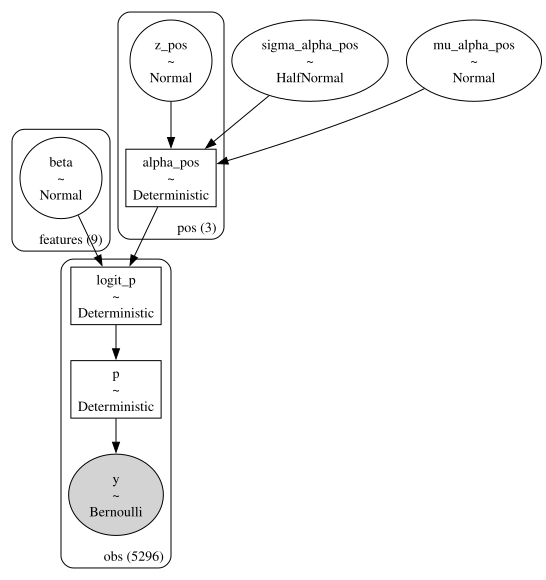

In [40]:
## setting up the hierarchy -> same model just without a player effect
with pm.Model(coords=new_coords) as non_centered_pos_avg_model:

    ## random effects for the groups
    ## pos group level
    z_pos = pm.Normal('z_pos', mu=0, sigma=1, dims='pos') ## non-centered parameterization
    sigma_alpha_pos = pm.HalfNormal('sigma_alpha_pos', sigma=1)
    mu_alpha_pos = pm.Normal('mu_alpha_pos', mu=0, sigma=1)
    alpha_pos = pm.Deterministic('alpha_pos', mu_alpha_pos + sigma_alpha_pos * z_pos, dims='pos')

    ## fixed effects 
    beta = pm.Normal('beta', mu=0, sigma=0.5, dims='features')

    ## log-odds model
    logit_p = pm.Deterministic('logit_p', alpha_pos[pos_indices] + beta.dot(X.T), dims='obs')
    # logit_p = pm.Deterministic('logit_p', alpha_pos[pos_indices] + alpha_player[player_indices], dims='obs')

    ## taking the inverse of the logit (putting it into the 0-1 scale)
    p = pm.Deterministic('p', pm.math.sigmoid(logit_p), dims='obs')

    ## outputs ... 
    y = pm.Bernoulli('y', p=p, observed=y_values, dims='obs')

pm.model_to_graphviz(non_centered_pos_avg_model)

In [41]:
with non_centered_pos_avg_model:
    non_centered_pos_avg_trace = pm.sample(1000, tune=2000, target_accept=0.99, nuts_sampler='numpyro', random_seed=RANDOM_SEED)

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

There were 6 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Computed from 4000 posterior samples and 5296 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1626.13    45.30
p_loo       11.58        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     5296  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

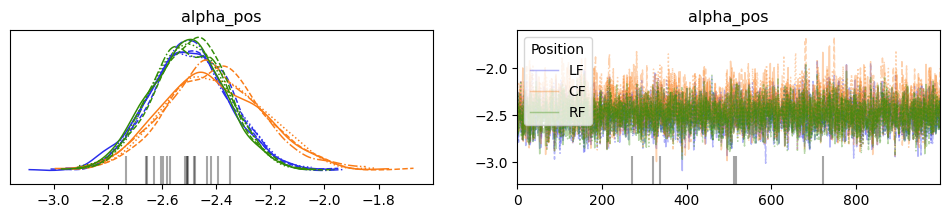

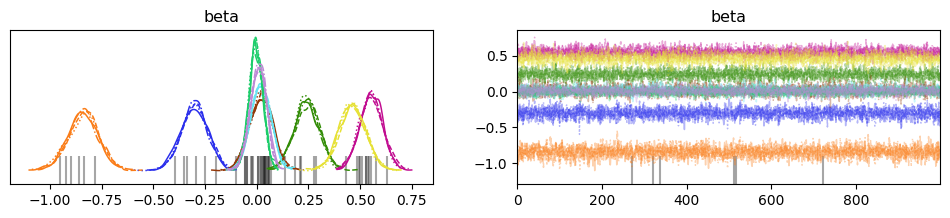

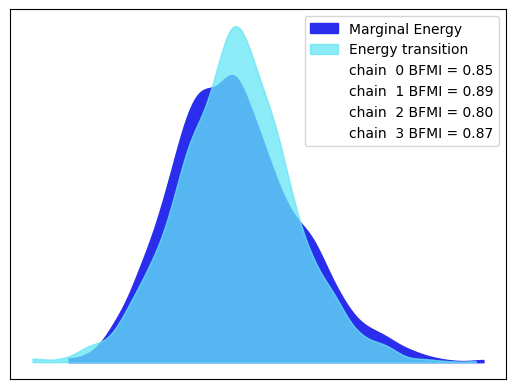

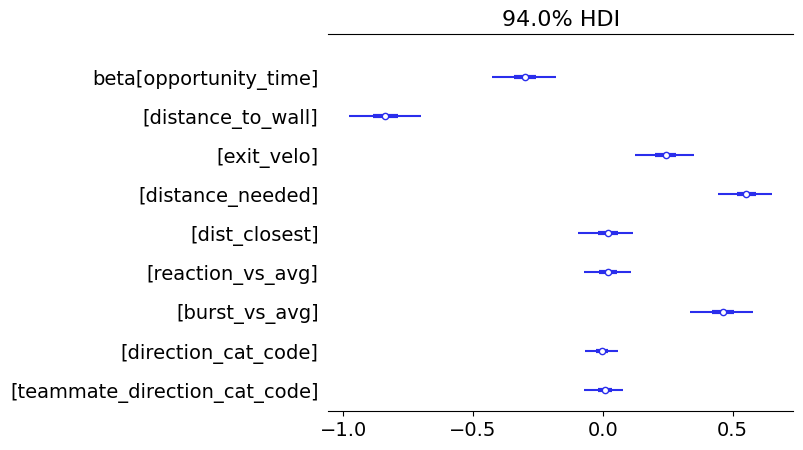

In [42]:
az.summary(non_centered_pos_avg_trace, var_names=['~p', '~logit_p'], round_to=2)

axes = az.plot_trace(non_centered_pos_avg_trace, var_names=['alpha_pos'])
posterior_ax = axes[0, 1]
pos_labels = ['LF' if i == 7 else 'CF' if i == 8 else 'RF' for i in new_coords['pos']]
lines = posterior_ax.lines
n_chains = non_centered_pos_avg_trace.posterior.chain.size
lines_to_label = lines[:len(pos_labels) * n_chains][::n_chains]
for i, j in zip(lines_to_label, pos_labels):
    i.set_label(j)
posterior_ax.legend(title="Position", loc='upper left')

az.plot_trace(non_centered_pos_avg_trace, var_names=['beta'])
az.plot_energy(non_centered_pos_avg_trace)
az.summary(non_centered_pos_avg_trace, var_names=['beta'], round_to=3)
az.plot_forest(non_centered_pos_avg_trace, var_names=["beta"], combined=True, hdi_prob=0.94)
az.summary(non_centered_pos_avg_trace, var_names=['alpha_pos']).sort_values(by='mean', ascending=False)

with non_centered_pos_avg_model:
    pm.compute_log_likelihood(non_centered_pos_avg_trace)
az.loo(non_centered_pos_avg_trace, non_centered_pos_avg_model)

In [179]:
pos_avg = primary_pos_aoe_players.groupby('pos')[['total_attempts', 'agg_attempts']].sum().reset_index().copy()
pos_avg.loc[:, 'agg_rate'] = pos_avg['agg_attempts'] / pos_avg['total_attempts']
pos_avg.loc[:, 'pos_code'] = pos_avg['pos'].map(lambda x: 7 if x=='LF' else 8 if x=='8' else 9)
pos_avg

,pos,total_attempts,agg_attempts,agg_rate,pos_code
0,CF,1770,220,0.124294,9
1,LF,1707,188,0.110135,7
2,RF,1829,176,0.096227,9


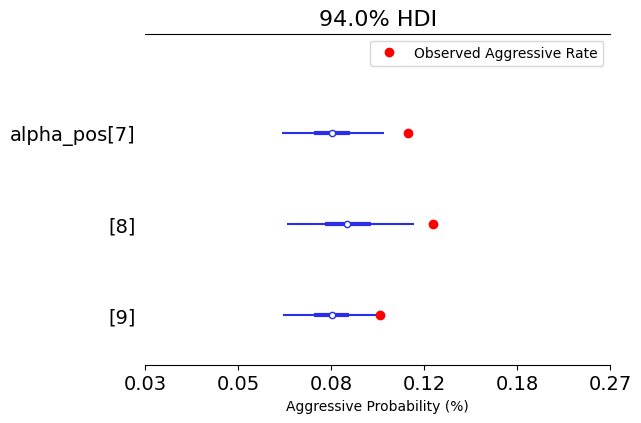

In [182]:
agg_rates = pos_avg.set_index('pos').sort_values(by='pos_code', ascending=True)['agg_rate'].values
(ax,) = az.plot_forest(non_centered_pos_avg_trace, var_names=["alpha_pos"], combined=True)
agg_rates_logit = logit(agg_rates)
ax.plot(agg_rates_logit[::-1], ax.get_yticks(), 'ro', label="Observed Aggressive Rate")
ax.set_xlabel("Aggressive Probability (%)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{logit_to_prob(x):.2f}")) ## changes the log-odds to probability
ax.set_xlim(-3.5, -1)
ax.legend(loc="upper right")

In [155]:
az.summary(non_centered_pos_avg_trace, var_names=['~logit_p', '~p'], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
z_pos[7],-0.33,0.79,-1.75,1.24,0.02,0.01,1802.22,2031.91,1.00
z_pos[8],0.15,0.83,-1.41,1.74,0.02,0.01,1780.49,1915.98,1.00
z_pos[9],-0.36,0.78,-1.81,1.13,0.02,0.01,2162.68,2570.61,1.00
mu_alpha_pos,-2.38,0.31,-2.88,-1.77,0.01,0.02,1024.27,752.83,1.01
beta[opportunity_time],-0.30,0.06,-0.43,-0.18,0.00,0.00,2836.50,2643.69,1.00
beta[distance_to_wall],-0.84,0.07,-0.98,-0.70,0.00,0.00,2699.92,2806.97,1.00
beta[exit_velo],0.24,0.06,0.12,0.35,0.00,0.00,2808.18,2901.88,1.00
beta[distance_needed],0.55,0.06,0.44,0.65,0.00,0.00,3728.02,2619.22,1.00
beta[dist_closest],0.02,0.06,-0.09,0.12,0.00,0.00,3260.19,2806.97,1.00
beta[reaction_vs_avg],0.02,0.05,-0.07,0.11,0.00,0.00,3058.17,2321.72,1.00


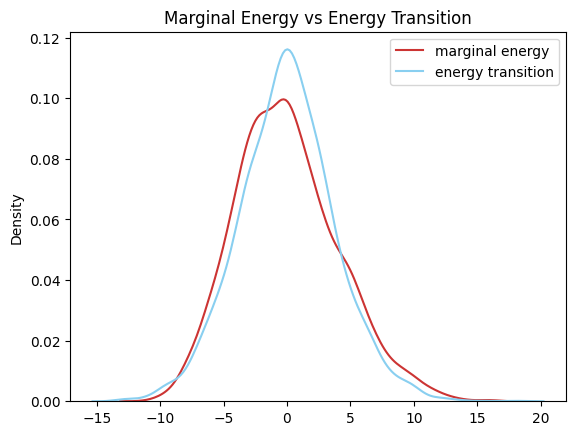

In [183]:
energy = non_centered_pos_avg_trace.sample_stats['energy'].values.ravel()
energy_diff = np.diff(energy)
plt.figure()
sns.kdeplot(energy - energy.mean(), label='marginal energy', color=red_color)
sns.kdeplot(energy_diff, label='energy transition', color=baby_blue_color)
plt.legend()
plt.title('Marginal Energy vs Energy Transition')
plt.show()

In [153]:
az.summary(non_centered_pos_avg_trace, var_names=['beta'], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[opportunity_time],-0.30,0.06,-0.43,-0.18,0.0,0.0,2836.50,2643.69,1.0
beta[distance_to_wall],-0.84,0.07,-0.98,-0.70,0.0,0.0,2699.92,2806.97,1.0
beta[exit_velo],0.24,0.06,0.12,0.35,0.0,0.0,2808.18,2901.88,1.0
beta[distance_needed],0.55,0.06,0.44,0.65,0.0,0.0,3728.02,2619.22,1.0
beta[dist_closest],0.02,0.06,-0.09,0.12,0.0,0.0,3260.19,2806.97,1.0
beta[reaction_vs_avg],0.02,0.05,-0.07,0.11,0.0,0.0,3058.17,2321.72,1.0
beta[burst_vs_avg],0.46,0.06,0.34,0.58,0.0,0.0,3065.61,2791.60,1.0
beta[direction_cat_code],-0.00,0.03,-0.07,0.06,0.0,0.0,3227.93,2750.57,1.0
beta[teammate_direction_cat_code],0.01,0.04,-0.07,0.08,0.0,0.0,2515.45,2764.50,1.0


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

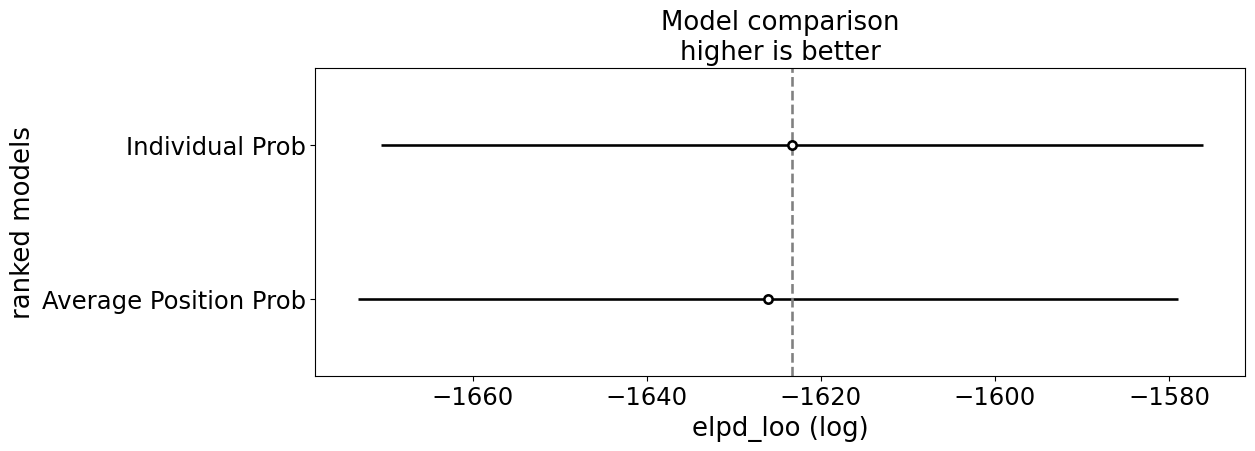

In [43]:
model_compare = az.compare(
    {
        "Individual Prob": non_centered_individual_player_trace,
        "Average Position Prob": non_centered_pos_avg_trace,
    }, method='BB-pseudo-BMA'
)
az.plot_compare(model_compare, figsize=(12, 4), insample_dev=False)

In [ ]:
# with non_centered_pos_avg_model:
#     X_data = pm.Data('X_data', X)
#     position_ind = pm.Data('pos_idx', pos_indices.astype(int))

In [79]:
def average_prob_prob_metric(df: pd.DataFrame, game_str_id: str):
    """
    Finds the average player's aggressive probability at the position of the person who made the "attempt" in that game_str_id
    Also includes the probability's 94% HDI
    
    Arguments: df: Dataframe, game_str_id: game_str_id
    """
    df = df.copy()
    df = df[df['game_str_id'] == game_str_id].reset_index(drop=True).copy()
    df = df[['game_str_id', 'player_name', 'player_idx', 'pos', 'pos_idx',
             'opportunity_time', 'distance_to_wall', 'exit_velo', 
             'distance_needed', 'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 
             'direction_cat_code', 'teammate_direction_cat_code']].copy()

    X = df[['opportunity_time', 'distance_to_wall', 'exit_velo', 'distance_needed', 
           'dist_closest', 'reaction_vs_avg', 'burst_vs_avg', 'direction_cat_code', 
           'teammate_direction_cat_code']].values.flatten()
    
    player_pos = df['pos'].iloc[0]

    ## gets the posterior samples for the player's pos, and the beta coefs
    alpha_pos = non_centered_pos_avg_trace.posterior['alpha_pos'].sel(pos=player_pos).values.flatten()
    betas_mcmc_samples = non_centered_pos_avg_trace.posterior['beta'].values
    
    ## reshapes the samples to be in the form: n x d (n obs and d features) instead of: chain num x n x d
    betas_mcmc_samples_flattened = betas_mcmc_samples.reshape(-1, betas_mcmc_samples.shape[-1])
    logit_samples =  alpha_pos + betas_mcmc_samples_flattened.dot(X.T)

    ## inverses the logit log odd into the sigmoid function (scale of 0 to 1)
    p_samples = 1 / (1 + np.exp(-logit_samples))
    mean_p = np.mean(p_samples)
    hdi = az.hdi(p_samples, hdi_prob=0.94)

    return np.array([mean_p, hdi[0], hdi[1]])

In [80]:
average_prob_prob_metric(filtered_bayesian_data, 'y1_d001_CGA_QEA_108')

array([0.16178382, 0.12789006, 0.19656094])

In [45]:
average_prob_prob_dict = metric_into_dict(filtered_bayesian_data, average_prob_prob_metric)
average_prob_prob_df = pd.DataFrame.from_dict(average_prob_prob_dict, orient='index', columns=['avg_pos_prob', 'avg_prob_hdi_low', 'avg_prob_hdi_high']).reset_index(names=['game_str_id']).copy()
filtered_bayesian_data = filtered_bayesian_data.merge(average_prob_prob_df, on='game_str_id', how='left').copy()
filtered_bayesian_data.loc[:, 'avg_hdi_range'] = filtered_bayesian_data['avg_prob_hdi_high'] - filtered_bayesian_data['avg_prob_hdi_low']
# filtered_bayesian_data[['avg_pos_prob', 'avg_prob_hdi_low', 'avg_prob_hdi_high', 'avg_hdi_range']] = filtered_bayesian_data[['avg_pos_prob', 'avg_prob_hdi_low', 'avg_prob_hdi_high', 'avg_hdi_range']] * 100

In [46]:
filtered_bayesian_data['avg_hdi_range'].describe()

count    5296.000000
mean        0.049808
std         0.033078
min         0.001545
25%         0.025738
50%         0.040488
75%         0.067657
max         0.357605
Name: avg_hdi_range, dtype: float64

In [47]:
filtered_bayesian_data['avg_hdi_range'].max()

0.35760459178371473

### Aggression Over Expected

In [49]:
filtered_bayesian_data = pd.read_csv('filtered_bayesian_data.csv').iloc[:, 1:].copy()

In [50]:
aoe_values = filtered_bayesian_data[['game_str_id', 'indiv_prob', 'avg_pos_prob']].copy()
aoe_values

,game_str_id,indiv_prob,avg_pos_prob
0,y1_d001_CGA_QEA_240,0.038041,0.039337
1,y1_d001_CGA_QEA_256,0.039585,0.050781
2,y1_d001_CGA_QEA_195,0.047078,0.042951
3,y1_d001_CGA_QEA_262,0.086413,0.085310
4,y1_d001_CGA_QEA_274,0.028704,0.026437
...,...,...,...
5291,y2_d098_YJD_RZQ_31,0.174969,0.156515
5292,y2_d098_YJD_RZQ_27,0.082982,0.095977
5293,y2_d098_YJD_RZQ_13,0.083338,0.084545
5294,y2_d098_YJD_RZQ_259,0.178151,0.159954


In [51]:
bayesian_data = bayesian_data.merge(aoe_values, on='game_str_id', how='left').copy()
bayesian_data

,game_str_id,distance_traveled_7,distance_traveled_8,distance_traveled_9,opportunity_time,hang_time,direction_angle_7,direction_angle_8,direction_angle_9,distance_needed_7,distance_needed_8,distance_needed_9,sprint_speed_7,sprint_speed_8,sprint_speed_9,distance_to_wall,launch_angle,exit_velo,is_out_catch,is_wall_ball,wall_ball_pos_z,closest_fielder_to_catch_point,player_attempt,whiffed_catch,reaction_7,reaction_8,reaction_9,burst_7,burst_8,burst_9,route_7,route_8,route_9,play_per_game,game_str,top_bottom_inning,left_field,center_field,right_field,distance_needed,distance_traveled,direction_angle,sprint_speed,reaction,burst,route,year,away_team,home_team,p_catch,pred_catch,difficulty_level,player_attempt_id,aggressive_attempt,direction_closest,dist_closest,closest_pos,expected_reaction_7,expected_reaction_8,expected_reaction_9,expected_burst_7,expected_burst_8,expected_burst_9,expected_route_7,expected_route_8,expected_route_9,expected_reaction,expected_burst,expected_route,reaction_vs_avg,burst_vs_avg,route_vs_avg,jump,indiv_prob,avg_pos_prob
0,y1_d001_CGA_QEA_240,10.851247,9.086522,2.155856,3.20,2.80,In Left,In Left,Back Left,12.824938,153.616141,242.682589,5.718944,3.534968,0.970684,69.884915,45.078858,94.377383,1.0,0,NaN,7.0,7.0,0.0,2.081028,3.788840,1.181984,8.322920,5.490593,1.015666,10.253843,9.387799,1.651421,240.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,12.824938,10.851247,In Left,5.718944,2.081028,8.322920,10.253843,y1,CGA,QEA,0.95,1,1 Star,CGA-1198,0,Back Right,141.517392,8,4.489555,5.552747,4.847996,14.769818,21.388579,16.402179,16.715047,24.664289,18.517882,4.489555,14.769818,16.715047,-2.408527,-6.446898,-6.461204,-15.316629,0.038041,0.039337
1,y1_d001_CGA_QEA_256,40.752090,51.366908,41.555113,3.70,3.25,In Right,In Right,In Left,146.361479,71.571528,93.250419,16.544438,24.097861,16.662136,157.590665,39.835271,71.875289,0.0,0,NaN,8.0,8.0,0.0,6.087127,4.788836,5.478716,23.904072,29.014366,25.389299,29.319713,34.218190,30.931913,256.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,71.571528,51.366908,In Right,24.097861,4.788836,29.014366,34.218190,y1,CGA,QEA,0.10,0,5 Star,QEA-0235,0,In Left,105.042661,7,6.039466,6.232328,6.142291,20.915445,23.882019,21.000666,25.577313,28.458469,25.649068,6.232328,23.882019,28.458469,-1.443492,5.132347,5.759721,9.448576,0.039585,0.050781
2,y1_d001_CGA_QEA_195,5.931540,17.049194,19.783084,2.45,2.05,In Right,In Right,In,214.763726,173.878553,113.523389,3.633669,11.467247,15.454587,197.832670,56.395341,70.778037,0.0,0,NaN,9.0,9.0,0.0,3.171357,6.864249,4.589234,2.881922,11.467247,15.454587,5.968212,15.963336,18.805976,195.0,y1_d001_CGA_QEA,0.0,CGA-1198,CGA-1547,CGA-1929,113.523389,19.783084,In,15.454587,4.589234,15.454587,18.805976,y1,CGA,QEA,0.00,0,5 Star,CGA-1929,0,Back Left,146.290127,8,6.259301,6.143275,6.843637,17.113446,20.990013,18.451234,22.846893,26.553701,25.504426,6.843637,18.451234,25.504426,-2.254403,-2.996646,-6.698450,-11.949500,0.047078,0.042951
3,y1_d001_CGA_QEA_262,22.839094,5.672331,2.289652,2.50,2.05,In,In Left,In Left,80.313315,165.692225,232.381521,15.870060,3.218863,1.545573,127.607913,52.200602,90.253353,0.0,0,NaN,7.0,7.0,0.0,6.873703,3.139336,1.626320,16.468740,3.361939,0.780074,23.022843,6.304819,2.222111,262.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,80.313315,22.839094,In,15.870060,6.873703,16.468740,23.022843,y1,CGA,QEA,0.00,0,5 Star,QEA-0249,0,Back Right,139.042699,8,6.280181,6.487292,6.704107,19.519095,24.055905,20.900068,24.871455,29.525415,26.967181,6.280181,19.519095,24.871455,0.593522,-3.050355,-1.848612,-4.305445,0.086413,0.085310
4,y1_d001_CGA_QEA_274,16.153562,56.441888,33.625889,5.10,4.65,In Right,In Right,Back Left,215.824188,89.689035,29.527484,3.972489,16.521860,12.682216,90.206290,39.664283,73.064776,1.0,0,NaN,9.0,9.0,0.0,2.245274,4.998017,5.315608,6.133556,23.692122,17.504153,7.464141,28.981189,21.710668,274.0,y1_d001_CGA_QEA,1.0,QEA-0249,QEA-0235,QEA-0252,29.527484,33.625889,Back Left,12.682216,5.315608,17.504153,21.710668,y1,CGA,

In [52]:
bayesian_data.loc[:, 'AOE'] = (bayesian_data['indiv_prob'] - bayesian_data['avg_pos_prob'])

In [55]:
## updating the player_metric_dict function to incorporate AOE
def player_metric_dict(df: pd.DataFrame, pos: str):
    """
    Creates a dictionary for pos that calculates several metrics for every player in that pos

    Arguments: df: Dataframe, pos: position name (left_field, center_field, right_field)
    """
    if pos == 'left_field':
        pos_code = 7
    if pos == 'center_field':
        pos_code = 8
    if pos == 'right_field':
        pos_code = 9

    pos_dict = {}
    for i in df[pos].unique():
        df_player = df[df[pos] == i]
        df_attempt = df_player[df_player['player_attempt'] == pos_code]
        pos_dict[i] = {'metrics': 
                        {'pos': pos_code,
                            'appearances': df_player.shape[0],
                            'AOE': df_player['AOE'].sum(),
                            'max_speed': df_player['sprint_speed'].max(),
                            'total_attempts': df_attempt.shape[0],
                            'agg_attempts': df_attempt['aggressive_attempt'].sum(),
                            'agg_successes': df_attempt[df_attempt['is_out_catch'] == 1]['aggressive_attempt'].sum(),
                            'catch%': df_attempt['is_out_catch'].mean(),
                            'catches_made': df_attempt['is_out_catch'].sum(),
                            'oaa': round((df_attempt['is_out_catch'] - df_attempt['p_catch']).sum(), 1),

                            # 'reaction': df_attempt['reaction_vs_avg'].mean(),
                            # 'burst': df_attempt['burst_vs_avg'].mean(),
                            # 'route': df_attempt['route_vs_avg'].mean(),
                            # 'jump': df_attempt['reaction_vs_avg'].mean() + df_attempt['burst_vs_avg'].mean() + df_attempt['route_vs_avg'].mean(),

                            '5_star_opps': df_attempt[df_attempt['difficulty_level'] == '5 Star'].shape[0],
                            '5_star_successes': df_attempt[df_attempt['difficulty_level'] == '5 Star']['is_out_catch'].sum(),
                            '5_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '5 Star']['aggressive_attempt'].sum(),
                            '5_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '5 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '4_star_opps': df_attempt[df_attempt['difficulty_level'] == '4 Star'].shape[0],
                            '4_star_successes': df_attempt[df_attempt['difficulty_level'] == '4 Star']['is_out_catch'].sum(),
                            '4_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '4 Star']['aggressive_attempt'].sum(),
                            '4_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '4 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),
                            
                            '3_star_opps': df_attempt[df_attempt['difficulty_level'] == '3 Star'].shape[0],
                            '3_star_successes': df_attempt[df_attempt['difficulty_level'] == '3 Star']['is_out_catch'].sum(),
                            '3_Star_agg_attempts': df_attempt[df_attempt['difficulty_level'] == '3 Star']['aggressive_attempt'].sum(),
                            '3_star_agg_successes': df_attempt[(df_attempt['difficulty_level'] == '3 Star') & (df_attempt['is_out_catch'] == 1)]['aggressive_attempt'].sum(),

                            '2_star_opps': df_attempt[df_attempt['difficulty_level'] == '2 Star'].shape[0],
                            '2_star_successes': df_attempt[df_attempt['difficulty_level'] == '2 Star']['is_out_catch'].sum(),

                            '1_star_opps': df_attempt[df_attempt['difficulty_level'] == '1 Star'].shape[0],
                            '1_star_successes': df_attempt[df_attempt['difficulty_level'] == '1 Star']['is_out_catch'].sum(),
                        }
                    }
    return pos_dict

In [56]:
left_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'left_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

center_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'center_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

right_field_players = (pd.DataFrame.from_dict({player: data['metrics'] for player, data in player_metric_dict(bayesian_data, 'right_field').items()}, orient='index')
    .reset_index(names=['player_name'])
    .fillna(0)
    .sort_values(by='agg_attempts', ascending=False)
    )

aoe_players = (pd.concat([left_field_players, center_field_players, right_field_players])
               .sort_values(by='AOE', ascending=False)
               .reset_index(drop=True)
               .copy()
               )
# aoe_players['AOE'] = scaler.fit_transform(aoe_players[['AOE']])

In [57]:
## takes the player's stats for their primary position
aoe_player_stats = aoe_players.groupby('player_name').agg({'appearances': 'sum',
                                                                        'AOE': 'sum',
                                                                        # 'oaa': 'sum',
                                                                        'max_speed': 'max',
                                                                        'total_attempts': 'sum',
                                                                        'catches_made': 'sum',
                                                                        'agg_attempts': 'sum',
                                                                        'agg_successes': 'sum',
                                                                        '5_star_opps': 'sum',
                                                                        '5_star_successes': 'sum',
                                                                        '5_Star_agg_attempts': 'sum',
                                                                        '5_star_agg_successes': 'sum',
                                                                        '4_star_opps': 'sum',
                                                                        '4_star_successes': 'sum',
                                                                        '4_Star_agg_attempts': 'sum',
                                                                        '4_star_agg_successes': 'sum',
                                                                        '3_star_opps': 'sum',
                                                                        '3_star_successes': 'sum',
                                                                        '3_Star_agg_attempts': 'sum',
                                                                        '3_star_agg_successes': 'sum',
                                                                        '2_star_opps': 'sum',
                                                                        '2_star_successes': 'sum',
                                                                        '1_star_opps': 'sum',
                                                                        '1_star_successes': 'sum',
                                        }).sort_values(by='agg_attempts', ascending=False).reset_index().copy()


primary_pos_aoe_players = aoe_player_stats.sort_values('appearances', ascending=False).drop_duplicates('player_name').copy()
primary_pos_aoe_players = primary_pos_aoe_players.merge(aoe_players[['player_name', 'oaa', 'pos']], on='player_name', how='left').drop_duplicates('player_name').copy()
primary_pos_aoe_players

,player_name,appearances,AOE,max_speed,total_attempts,catches_made,agg_attempts,agg_successes,5_star_opps,5_star_successes,5_Star_agg_attempts,5_star_agg_successes,4_star_opps,4_star_successes,4_Star_agg_attempts,4_star_agg_successes,3_star_opps,3_star_successes,3_Star_agg_attempts,3_star_agg_successes,2_star_opps,2_star_successes,1_star_opps,1_star_successes,oaa,pos
0,YJD-0327,456,-3.879449,29.684643,129,69.0,9,3,47,0.0,4,0,8,0.0,2,0,11,11.0,3,3,13,11.0,50,47.0,0.5,8
3,YJD-0340,452,-1.499771,29.236034,138,79.0,11,2,45,0.0,6,0,9,2.0,1,0,19,15.0,4,2,15,13.0,50,49.0,-3.1,7
6,RZQ-0274,444,5.189696,28.730162,164,97.0,30,12,58,2.0,14,1,17,10.0,7,4,16,13.0,9,7,12,11.0,61,61.0,6.1,8
9,YJD-0397,423,-4.047496,28.049701,117,69.0,8,1,38,1.0,5,0,10,3.0,2,0,10,7.0,1,1,12,12.0,47,46.0,4.1,9
11,QEA-0249,402,-0.537889,28.521837,110,64.0,14,6,36,2.0,6,2,4,0.0,2,0,16,9.0,6,4,16,15.0,38,38.0,2.3,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524,YJD-0072,1,-0.000963,9.164584,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,1,1.0,0.1,7
525,YJD-0075,1,-0.000963,9.164584,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,8
526,YJD-0224,1,0.000392,22.809593,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,1,1.0,0,0,0,0.0,0,0.0,0.2,7
527,YJD-0361,1,0.000392,22.809593,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,8


In [186]:
filtered_bayesian_data.to_csv('Team 15-Game AOE Results.csv')

In [67]:
# primary_pos_aoe_players.to_csv('players_w_aoe.csv')
primary_pos_aoe_players = pd.read_csv('players_w_aoe.csv').iloc[:, 1:].copy()

In [68]:
primary_pos_aoe_players

,player_name,appearances,AOE,max_speed,total_attempts,catches_made,agg_attempts,agg_successes,5_star_opps,5_star_successes,5_Star_agg_attempts,5_star_agg_successes,4_star_opps,4_star_successes,4_Star_agg_attempts,4_star_agg_successes,3_star_opps,3_star_successes,3_Star_agg_attempts,3_star_agg_successes,2_star_opps,2_star_successes,1_star_opps,1_star_successes,oaa,pos,5_star_agg_rate,4_star_agg_rate,3_star_agg_rate,agg_success_rate,agg_attempt_rate
0,YJD-0327,456,-3.879449,29.684643,129,69.0,9,3,47,0.0,4,0,8,0.0,2,0,11,11.0,3,3,13,11.0,50,47.0,0.5,CF,0.000000,0.000000,100.000000,33.333333,0.069767
1,YJD-0340,452,-1.499771,29.236034,138,79.0,11,2,45,0.0,6,0,9,2.0,1,0,19,15.0,4,2,15,13.0,50,49.0,-3.1,LF,0.000000,0.000000,50.000000,18.181818,0.079710
2,RZQ-0274,444,5.189696,28.730162,164,97.0,30,12,58,2.0,14,1,17,10.0,7,4,16,13.0,9,7,12,11.0,61,61.0,6.1,CF,7.142857,57.142857,77.777778,40.000000,0.182927
3,YJD-0397,423,-4.047496,28.049701,117,69.0,8,1,38,1.0,5,0,10,3.0,2,0,10,7.0,1,1,12,12.0,47,46.0,4.1,RF,0.000000,0.000000,100.000000,12.500000,0.068376
4,QEA-0249,402,-0.537889,28.521837,110,64.0,14,6,36,2.0,6,2,4,0.0,2,0,16,9.0,6,4,16,15.0,38,38.0,2.3,LF,33.333333,0.000000,66.666667,42.857143,0.127273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,YJD-0072,1,-0.000963,9.164584,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,1,1.0,0.1,LF,0.000000,0.000000,0.000000,0.000000,0.000000
396,YJD-0075,1,-0.000963,9.164584,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,CF,0.000000,0.000000,0.000000,0.000000,0.000000
397,YJD-0224,1,0.000392,22.809593,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,1,1.0,0,0,0,0.0,0,0.0,0.2,LF,0.000000,0.000000,0.000000,0.000000,0.000000
398,YJD-0361,1,0.000392,22.809593,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,CF,0.000000,0.000000,0.000000,0.000000,0.000000


In [59]:
primary_pos_aoe_players[primary_pos_aoe_players['appearances'] >= 100].sort_values(by='AOE', ascending=False)

,player_name,appearances,AOE,max_speed,total_attempts,catches_made,agg_attempts,agg_successes,5_star_opps,5_star_successes,5_Star_agg_attempts,5_star_agg_successes,4_star_opps,4_star_successes,4_Star_agg_attempts,4_star_agg_successes,3_star_opps,3_star_successes,3_Star_agg_attempts,3_star_agg_successes,2_star_opps,2_star_successes,1_star_opps,1_star_successes,oaa,pos
2,RZQ-0274,444,5.189696,28.730162,164,97.0,30,12,58,2.0,14,1,17,10.0,7,4,16,13.0,9,7,12,11.0,61,61.0,6.1,8
14,RZQ-0014,238,2.799169,27.748097,71,38.0,10,5,29,0.0,1,0,4,1.0,3,0,11,10.0,6,5,4,4.0,23,23.0,0.9,9
17,RZQ-0409,219,1.932057,27.212260,72,40.0,13,5,29,1.0,6,0,5,2.0,4,2,7,6.0,3,3,8,8.0,23,23.0,0.5,7
21,RZQ-0275,179,1.655433,28.240688,66,40.0,12,3,17,0.0,6,0,7,1.0,2,0,7,5.0,4,3,6,5.0,29,29.0,-2.3,8
6,RZQ-0346,374,1.353764,28.607060,111,66.0,13,9,40,1.0,5,1,7,4.0,2,2,11,10.0,6,6,11,9.0,42,42.0,5.6,9
24,RZQ-0214,148,1.279988,28.730162,43,21.0,4,0,16,0.0,2,0,4,1.0,1,0,2,1.0,1,0,8,8.0,13,11.0,1.1,9
29,RZQ-0059,106,1.260001,27.748097,37,14.0,7,1,17,0.0,5,0,4,2.0,2,1,2,0.0,0,0,5,5.0,9,7.0,-2.4,7
20,RZQ-0333,199,0.979857,27.377297,74,41.0,5,1,27,0.0,4,0,3,1.0,0,0,7,6.0,1,1,9,9.0,28,25.0,0.4,7
27,RZQ-0244,113,0.722576,28.730162,30,15.0,0,0,15,0.0,0,0,0,0.0,0,0,2,2.0,0,0,4,4.0,9,9.0,0.1,7
25,RZQ-0143,143,0.664557,28.222682,40,25.0,7,2,9,0.0,3,0,1,0.0,1,0,5,4.0,3,2,8,7.0,17,14.0,-2.9,7


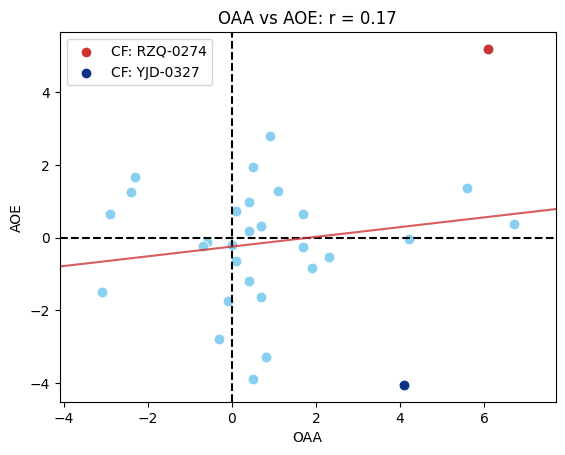

In [60]:
temp = primary_pos_aoe_players[primary_pos_aoe_players['appearances'] >= 100].reset_index(drop=True).copy()

plt.figure()
sns.scatterplot(data=temp, x='oaa', y='AOE', color=baby_blue_color, s=60)

plt.axvline(x=0, linestyle='--', color='black')
plt.axhline(y=0, linestyle='--', color='black')
plt.xlabel('OAA')
plt.ylabel('AOE')
r = pearsonr(temp['oaa'], temp['AOE'])[0]
plt.title(f'OAA vs AOE: r = {round(r, 2)}')

m, b = np.polyfit(temp['oaa'], temp['AOE'], 1)
x_values = np.linspace(temp['oaa'].min() - 1, temp['oaa'].max() + 1)
y = m*x_values + b
plt.plot(x_values, y, color=red_color, alpha=0.8)
plt.xlim(temp['oaa'].min() - 1, temp['oaa'].max() + 1)
plt.scatter(x = temp.sort_values(by='oaa', ascending=False).iloc[1:]['oaa'].max(), y=temp['AOE'].max(), label='CF: RZQ-0274', color=red_color)
plt.scatter(x = temp.sort_values(by='oaa', ascending=False).iloc[4:]['oaa'].max(), y=temp['AOE'].min(), label='CF: YJD-0327', color='#0E3386')
plt.legend()
plt.show()

In [61]:
primary_pos_aoe_players['pos'] = primary_pos_aoe_players['pos'].map(lambda x: 'LF' if x==7 else 'CF' if x==8 else 'RF')
primary_pos_aoe_players

,player_name,appearances,AOE,max_speed,total_attempts,catches_made,agg_attempts,agg_successes,5_star_opps,5_star_successes,5_Star_agg_attempts,5_star_agg_successes,4_star_opps,4_star_successes,4_Star_agg_attempts,4_star_agg_successes,3_star_opps,3_star_successes,3_Star_agg_attempts,3_star_agg_successes,2_star_opps,2_star_successes,1_star_opps,1_star_successes,oaa,pos
0,YJD-0327,456,-3.879449,29.684643,129,69.0,9,3,47,0.0,4,0,8,0.0,2,0,11,11.0,3,3,13,11.0,50,47.0,0.5,CF
1,YJD-0340,452,-1.499771,29.236034,138,79.0,11,2,45,0.0,6,0,9,2.0,1,0,19,15.0,4,2,15,13.0,50,49.0,-3.1,LF
2,RZQ-0274,444,5.189696,28.730162,164,97.0,30,12,58,2.0,14,1,17,10.0,7,4,16,13.0,9,7,12,11.0,61,61.0,6.1,CF
3,YJD-0397,423,-4.047496,28.049701,117,69.0,8,1,38,1.0,5,0,10,3.0,2,0,10,7.0,1,1,12,12.0,47,46.0,4.1,RF
4,QEA-0249,402,-0.537889,28.521837,110,64.0,14,6,36,2.0,6,2,4,0.0,2,0,16,9.0,6,4,16,15.0,38,38.0,2.3,LF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,YJD-0072,1,-0.000963,9.164584,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,1,1.0,0.1,LF
396,YJD-0075,1,-0.000963,9.164584,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,CF
397,YJD-0224,1,0.000392,22.809593,1,1.0,0,0,0,0.0,0,0,0,0.0,0,0,1,1.0,0,0,0,0.0,0,0.0,0.2,LF
398,YJD-0361,1,0.000392,22.809593,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0,0,0.0,0,0.0,0.0,CF


In [184]:
primary_pos_aoe_players.to_csv('Team 15-AOE Results.csv')

In [62]:
primary_pos_aoe_players.loc[:, '5_star_agg_rate'] = primary_pos_aoe_players.apply(
    lambda x: (x['5_star_agg_successes'] / x['5_Star_agg_attempts']) * 100 if x['5_Star_agg_attempts'] >= 1 else 0, axis=1
    )

primary_pos_aoe_players.loc[:, '4_star_agg_rate'] = primary_pos_aoe_players.apply(
    lambda x: (x['4_star_agg_successes'] / x['4_Star_agg_attempts']) * 100 if x['4_Star_agg_attempts'] >= 1 else 0, axis=1
    )

primary_pos_aoe_players.loc[:, '3_star_agg_rate'] = primary_pos_aoe_players.apply(
    lambda x: (x['3_star_agg_successes'] / x['3_Star_agg_attempts']) * 100 if x['3_Star_agg_attempts'] >= 1 else 0, axis=1
    )

primary_pos_aoe_players.loc[:, 'agg_success_rate'] = primary_pos_aoe_players.apply(
    lambda x: (x['agg_successes'] / x['agg_attempts']) * 100 if x['agg_successes'] >= 1 else 0, axis=1
    )

In [63]:
primary_pos_aoe_players['agg_attempt_rate'] = primary_pos_aoe_players.apply(lambda x: (x['agg_attempts'] / x['total_attempts']) if x['total_attempts'] >= 1 else 0, axis=1)

In [65]:
## makes up the AOE leaderboard
top_5 = primary_pos_aoe_players.sort_values("AOE", ascending=False).head(5).copy()
bottom_5 = primary_pos_aoe_players.sort_values("AOE", ascending=True).head(5).sort_values(by='AOE', ascending=False).copy()
top_5["group"] = "Top 5"
bottom_5["group"] = "Bottom 5"
aoe_table = pd.concat([top_5, bottom_5], ignore_index=True)[["group", "player_name", "pos", "AOE", "oaa",
                                                            "5_star_agg_successes", "5_Star_agg_attempts", 
                                                            "4_star_agg_successes", "4_Star_agg_attempts", 
                                                            "3_star_agg_successes", "3_Star_agg_attempts",
                                                            'agg_attempts', 'agg_successes', 
                                                            '5_star_agg_rate', '4_star_agg_rate', '3_star_agg_rate',
                                                            'agg_success_rate',]]

top_rows = aoe_table.index[aoe_table["group"] == "Top 5"].tolist()
bottom_rows = aoe_table.index[aoe_table["group"] == "Bottom 5"].tolist()

aoe_gt_table = (gt.GT(aoe_table, rowname_col="player_name", groupname_col="group")
                .tab_header(title="Top and Bottom 5 Outfielders by Aggression Over Expected (AOE)")
                .tab_stubhead(label="Player")
                .fmt_number(columns="AOE", decimals=1)
                .fmt_number(columns="oaa", decimals=1)
                .fmt_number(columns="5_star_agg_rate", decimals=1)
                .fmt_number(columns="4_star_agg_rate", decimals=1)
                .fmt_number(columns="3_star_agg_rate", decimals=1)
                .fmt_number(columns="agg_success_rate", decimals=1)
                .cols_label(pos="Position", AOE="AOE", oaa="OAA | ", **{"5_star_agg_successes": "Outs", 
                                                                     "5_Star_agg_attempts": gt.html("<br>Aggressive</br> Attempts"), 
                                                                     "5_star_agg_rate": "%", 
                                                                     "4_star_agg_successes": "Outs", 
                                                                     "4_Star_agg_attempts": gt.html("<br>Aggressive</br> Attempts"), 
                                                                     "4_star_agg_rate": "%", 
                                                                     "3_star_agg_successes": "Outs", 
                                                                     "3_Star_agg_attempts": gt.html("<br>Aggressive</br> Attempts"), 
                                                                     "3_star_agg_rate": "%", 
                                                                     "agg_successes": "Outs", 
                                                                     "agg_attempts": gt.html("<br>Aggressive</br> Attempts"), 
                                                                     "agg_success_rate": "%",
                                                                     })
                .tab_spanner(label="5 Star Catch Prob (0-25%)", columns=["5_star_agg_successes", "5_Star_agg_attempts", "5_star_agg_rate"])
                .tab_spanner(label="4 Star Catch Prob (26-50%)", columns=["4_star_agg_successes", "4_Star_agg_attempts", "4_star_agg_rate"])
                .tab_spanner(label="3 Star Catch Prob (51-75%)", columns=["3_star_agg_successes", "3_Star_agg_attempts", "3_star_agg_rate"])
                .tab_spanner(label="Total", columns=["agg_successes", "agg_attempts", "agg_success_rate"])
                .tab_style(style=gt.style.fill(color=red_color), locations=gt.loc.body(rows=top_rows, columns=["AOE"]))
                .tab_style(style=gt.style.text(color="white", weight="bold"), locations=gt.loc.body(rows=top_rows, columns=["AOE"]))
                .tab_style(style=gt.style.fill(color=baby_blue_color), locations=gt.loc.body(rows=bottom_rows, columns=["AOE"]))
                .tab_style(style=gt.style.text(color="black", weight="bold"), locations=gt.loc.body(rows=bottom_rows, columns=["AOE"]))
                .cols_align("center")
                )
aoe_gt_table

# aoe_gt_table.save("AOE_leaderboard.png")

GT(_tbl_data=      group player_name pos       AOE  oaa  5_star_agg_successes  \
0     Top 5    RZQ-0274  CF  5.189696  6.1                     1   
1     Top 5    RZQ-0014  RF  2.799169  0.9                     0   
2     Top 5    RZQ-0409  LF  1.932057  0.5                     0   
3     Top 5    RZQ-0275  CF  1.655433 -2.3                     0   
4     Top 5    RZQ-0346  RF  1.353764  5.6                     1   
5  Bottom 5    YJD-0338  LF -1.736183 -0.1                     0   
6  Bottom 5    YJD-0366  LF -2.784018 -0.3                     0   
7  Bottom 5    YJD-0019  RF -3.272929  0.8                     1   
8  Bottom 5    YJD-0327  CF -3.879449  0.5                     0   
9  Bottom 5    YJD-0397  RF -4.047496  4.1                     0   

   5_Star_agg_attempts  4_star_agg_successes  4_Star_agg_attempts  \
0                   14                     4                    7   
1                    1                     0                    3   
2                    6                     2                    4   
3                    6                     0                    2   
4                    5                     2                    2   
5                    5                     1                    1   
6                    3                     0                    1   
7                    4                     1                    1   
8                    4                     0                    2   
9                    5                     0                    2   

   3_star_agg_successes  3_Star_agg_attempts  agg_attempts  agg_successes  \
0                     7                    9            30             12   
1                     5                    6            10              5   
2                     3                    3            13              5   
3                     3                    4            12              3   
4                     6                    6            13              9   
5                     2                    2             8              3   
6                     4                    4             8              4   
7                     2                    2             7              4   
8                     3                    3             9              3   
9                     1                    1             8              1   

   5_star_agg_rate  4_star_agg_rate  3_star_agg_rate  agg_success_rate  
0         7.142857        57.142857        77.777778         40.000000  
1         0.000000         0.000000        83.333333         50.000000  
2         0.000000        50.000000       100.000000         38.461538  
3         0.000000         0.000000        75.000000         25.000000  
4        20.000000       100.000000       100.000000         69.230769  
5         0.000000       100.000000       100.000000         37.500000  
6         0.000000         0.000000       100.000000         50.000000  
7        25.000000       100.000000       100.000000         57.142857  
8         0.000000         0.000000       100.000000         33.333333  
9         0.000000         0.000000       100.000000         12.500000  , _body=<great_tables._gt_data.Body object at 0x32ad0a3e0>, _boxhead=Boxhead([ColInfo(var='group', type=<ColInfoTypeEnum.row_group: 3>, column_label='group', column_align='center', column_width=None), ColInfo(var='player_name', type=<ColInfoTypeEnum.stub: 2>, column_label='player_name', column_align='center', column_width=None), ColInfo(var='pos', type=<ColInfoTypeEnum.default: 1>, column_label='Position', column_align='center', column_width=None), ColInfo(var='AOE', type=<ColInfoTypeEnum.default: 1>, column_label='AOE', column_align='center', column_width=None), ColInfo(var='oaa', type=<ColInfoTypeEnum.default: 1>, column_label='OAA | ', column_align='center', column_width=None), ColInfo(var='5_star_agg_successes', type=<ColInfoTypeEnum.default: 1>, column_label='Outs', column_align='center', column_width=None), Col